# FINC6028 Assignment 3 - Track A
## US large-cap equity long-short stock-ranking strategy

**Stakeholder.** A US long-short equity portfolio manager.

**Decision.** Each Friday after the close, rank all current S&P 500 stocks that pass the notebook's data-quality screen and choose which stocks to long and short for the following week.

**Modelling task.** Predict whether stock \(i\)'s next-week return will outperform the cross-sectional median next-week return of the tradable universe:

\[
\text{target}_{i,t}=1\{r_{i,t+1} > \text{median}_{j}(r_{j,t+1})\}.
\]

**Portfolio rule.** Long the top-ranked 20% and short the bottom-ranked 20%, equal-weighted within each leg, rebalanced weekly. The base transaction cost is 5 bps one-way, with sensitivity at 1 bps and 10 bps.

**Important limitation.** This notebook uses **current** S&P 500 constituents because point-in-time membership data is not freely available from the chosen public data stack. This creates survivorship bias: companies that left the index historically are excluded. The notebook does not pretend the universe is point-in-time.

## 0a) Installation

Run this cell first in Google Colab. If the packages are already installed, pip will simply report that the requirements are satisfied.

In [1]:
!pip -q install yfinance lxml tabulate xgboost

## 0b) Imports and Random Seeds

All randomness is pinned for reproducibility. The tree model is deliberately kept modest so the notebook can run top-to-bottom in Colab without specialist hardware.

In [2]:
import os
import random
import time
import warnings
from pathlib import Path
from textwrap import dedent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from xgboost import XGBClassifier

from IPython.display import display
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

OUTPUT_DIR = Path("a3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Random seed set to {RANDOM_SEED}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Random seed set to 42
Output directory: /Users/mingwang/Desktop/Finc 6028 A3/a3_outputs


## 1) Parameters

The sample starts in 2015 to provide a long enough panel while keeping runtime manageable. The initial training window is 156 weekly observations, approximately 3 years. The first out-of-sample predictions therefore begin only after the model has enough history.

`N_TARGET_UNIVERSE = None` means the notebook does **not** cap the universe at 200 names. It downloads the full current S&P 500 constituent list from `Ate329/top-us-stock-tickers` and keeps every stock that passes the continuous-history and data-coverage screens.

In [3]:
# =============================================================================
# 1) USER SETTINGS
# =============================================================================

SAMPLE_START = "2015-01-01"

# yfinance treats `end` as exclusive. A Saturday end date includes the Friday close.
# Set to None if you want the latest data available when rerunning the notebook.
SAMPLE_END = "2026-05-16"

FREQ = "W-FRI"
BENCHMARK = "SPY"

N_TARGET_UNIVERSE = None  # None = use all eligible current S&P 500 constituents after data-quality screens

# Freeze the modelling universe for reproducible group results.
# This 461-stock file is based on the S&P 500 source available on 2026-05-22,
# after the notebook's data-quality screens. It is not point-in-time membership.
# Set this to False only if you deliberately want to refresh the online source.
USE_FROZEN_UNIVERSE = True
FROZEN_UNIVERSE_PATH = Path("a3_frozen_universe_2026-05-22.csv")

UNIVERSE_SELECTION_WEEKS = 52
MIN_WEEKLY_COVERAGE = 0.98

MIN_TRAIN_WEEKS = 156
REFIT_EVERY_WEEKS = 4

COST_BPS_BASE = 5
COST_BPS_SENSITIVITY = [1, 5, 10]
QUANTILE_BASE = 0.20
QUANTILE_GRID = [0.10, 0.20, 0.30]

APPLY_VOL_TARGET = True
VOL_TARGET_ANNUAL = 0.10
VOL_LOOKBACK_WEEKS = 26
MAX_WEIGHT_SCALE = 1.50

VERBOSE = True

print("Key parameters")
print(f"  Sample: {SAMPLE_START} to {SAMPLE_END}")
target_universe_msg = "All eligible S&P 500 constituents" if N_TARGET_UNIVERSE is None else str(N_TARGET_UNIVERSE)
print(f"  Target universe size: {target_universe_msg}")
print(f"  Rebalance frequency: {FREQ}")
print(f"  Initial training window: {MIN_TRAIN_WEEKS} weeks")
print(f"  Refit frequency: every {REFIT_EVERY_WEEKS} weeks")
print(f"  Base portfolio: top/bottom {QUANTILE_BASE:.0%}, {COST_BPS_BASE} bps one-way cost")
print(f"  Vol targeting: {APPLY_VOL_TARGET}, target={VOL_TARGET_ANNUAL:.0%}, max scale={MAX_WEIGHT_SCALE:.1f}x")

Key parameters
  Sample: 2015-01-01 to 2026-05-16
  Target universe size: All eligible S&P 500 constituents
  Rebalance frequency: W-FRI
  Initial training window: 156 weeks
  Refit frequency: every 4 weeks
  Base portfolio: top/bottom 20%, 5 bps one-way cost
  Vol targeting: True, target=10%, max scale=1.5x


## 2) Universe Construction

For reproducibility, the default notebook uses a frozen modelling-universe file:

`a3_frozen_universe_2026-05-22.csv`

This file contains the 461 stocks used in the latest group rerun. It is based on the current S&P 500 source available on 2026-05-22, after applying the notebook's data-quality screens. We freeze this list because the online S&P 500 source is daily-updated; even a one-stock change can alter the cross-sectional median target, weekly ranks, portfolio weights, turnover, and robustness results.

The original online source remains in the code as a fallback:

`https://raw.githubusercontent.com/Ate329/top-us-stock-tickers/main/tickers/sp500.csv`

Set `USE_FROZEN_UNIVERSE = False` only if the group deliberately wants to refresh the online S&P 500 source and accept that results may change.

**Important survivorship-bias note.** This frozen file is still based on **current** S&P 500 membership, not point-in-time historical index membership. A production-quality point-in-time universe usually requires WRDS/CRSP, Compustat, Bloomberg, Refinitiv, or another paid institutional data source. This notebook explicitly discloses survivorship bias and does not pretend the universe is point-in-time.

In [4]:

# =============================================================================
# 2) UNIVERSE CONSTRUCTION HELPERS
# =============================================================================

SP500_TICKERS_URL = "https://raw.githubusercontent.com/Ate329/top-us-stock-tickers/main/tickers/sp500.csv"


def clean_yahoo_ticker(ticker):
    """Convert share-class symbols into Yahoo Finance format."""
    return str(ticker).strip().replace(".", "-").replace("/", "-")


def get_current_sp500_tickers():
    """Download current S&P 500 constituents from Ate329/top-us-stock-tickers."""
    raw = pd.read_csv(SP500_TICKERS_URL)
    if "symbol" not in raw.columns:
        raise ValueError(f"Expected a 'symbol' column in {SP500_TICKERS_URL}, got {list(raw.columns)}")

    meta = raw.copy()
    meta["Ticker"] = meta["symbol"].map(clean_yahoo_ticker)
    meta = meta.dropna(subset=["Ticker"]).drop_duplicates("Ticker").copy()

    if "name" in meta.columns:
        meta["Security"] = meta["name"].fillna(meta["Ticker"])
    else:
        meta["Security"] = meta["Ticker"]

    if "industry" in meta.columns:
        industry = meta["industry"].replace("", np.nan).fillna("Unavailable")
        meta["GICS Sector"] = industry
        meta["GICS Sub-Industry"] = industry
    else:
        meta["GICS Sector"] = "Unavailable"
        meta["GICS Sub-Industry"] = "Unavailable"

    keep_cols = ["Ticker", "Security", "GICS Sector", "GICS Sub-Industry"]
    optional_cols = [c for c in ["price", "marketCap", "volume", "industry"] if c in meta.columns]
    meta = meta[keep_cols + optional_cols].copy()

    # Preserve the repository's market-cap ordering where available, while dropping duplicates.
    tickers = meta["Ticker"].dropna().drop_duplicates().tolist()
    source = f"Ate329/top-us-stock-tickers current S&P 500 constituents ({len(tickers)} tickers)"
    return tickers, meta, source


def get_frozen_universe_tickers(path):
    """Load the locally frozen universe used for the presentation/report rerun."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Frozen universe file not found: {path}. "
            "Set USE_FROZEN_UNIVERSE=False to refresh the online S&P 500 source."
        )
    meta = pd.read_csv(path)
    if "Ticker" not in meta.columns:
        raise ValueError(f"Frozen universe file must contain a Ticker column: {path}")
    meta["Ticker"] = meta["Ticker"].map(clean_yahoo_ticker)
    meta = meta.dropna(subset=["Ticker"]).drop_duplicates("Ticker").copy()
    for col in ["Security", "GICS Sector", "GICS Sub-Industry"]:
        if col not in meta.columns:
            meta[col] = "Unavailable"
    meta = meta[["Ticker", "Security", "GICS Sector", "GICS Sub-Industry"]].copy()
    tickers = meta["Ticker"].tolist()
    source = f"Frozen modelling universe from {path.name} ({len(tickers)} tickers)"
    return tickers, meta, source


if USE_FROZEN_UNIVERSE:
    sp500_candidates, sp500_meta, universe_source = get_frozen_universe_tickers(FROZEN_UNIVERSE_PATH)
else:
    sp500_candidates, sp500_meta, universe_source = get_current_sp500_tickers()

print(universe_source)
print(f"Candidate tickers: {len(sp500_candidates)}")
print(sp500_candidates[:20])


Frozen modelling universe from a3_frozen_universe_2026-05-22.csv (461 tickers)
Candidate tickers: 461
['AAPL', 'META', 'AMZN', 'NFLX', 'MSFT', 'GOOGL', 'GE', 'GOOG', 'BAC', 'TSLA', 'GILD', 'DIS', 'BKNG', 'INTC', 'JPM', 'BIIB', 'XOM', 'C', 'WFC', 'CMCSA']


## 3) Download Daily Price and Volume Data

Prices use `auto_adjust=True`, so Yahoo's close series is adjusted for splits and dividends. Volume is unadjusted trading volume. The downloader works in chunks and keeps going if some tickers fail.

In [5]:
# =============================================================================
# 3) DOWNLOAD DATA
# =============================================================================

def _extract_field(raw, field):
    """Extract Close/Volume robustly across yfinance single- and multi-ticker outputs."""
    if raw is None or raw.empty:
        return pd.DataFrame()
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        level1 = raw.columns.get_level_values(1)
        if field in level0:
            out = raw[field].copy()
        elif field in level1:
            out = raw.xs(field, axis=1, level=1).copy()
        else:
            return pd.DataFrame(index=raw.index)
    else:
        if field not in raw.columns:
            return pd.DataFrame(index=raw.index)
        name = raw.attrs.get("ticker", field)
        out = raw[[field]].rename(columns={field: name})
    out.columns = [clean_yahoo_ticker(c) for c in out.columns]
    out.index = pd.to_datetime(out.index).tz_localize(None)
    return out


def download_yf_chunks(tickers, start, end=None, chunk_size=70, sleep_seconds=0.5, max_retries=2):
    """Download adjusted close and volume in chunks; return wide DataFrames plus failed chunks."""
    tickers = [clean_yahoo_ticker(t) for t in tickers]
    close_parts, volume_parts, failed = [], [], []
    chunks = [tickers[i:i + chunk_size] for i in range(0, len(tickers), chunk_size)]

    for k, chunk in enumerate(chunks, start=1):
        if VERBOSE:
            print(f"Downloading chunk {k:02d}/{len(chunks):02d}: {len(chunk)} tickers")
        ok = False
        last_exc = None
        for attempt in range(1, max_retries + 1):
            try:
                raw = yf.download(
                    tickers=chunk,
                    start=start,
                    end=end,
                    auto_adjust=True,
                    progress=False,
                    threads=False,
                    group_by="column",
                )
                close = _extract_field(raw, "Close")
                volume = _extract_field(raw, "Volume")
                if close.empty:
                    raise RuntimeError("empty Close download")
                close_parts.append(close)
                volume_parts.append(volume)
                ok = True
                break
            except Exception as exc:
                last_exc = exc
                time.sleep(sleep_seconds * attempt)
        if not ok:
            failed.extend(chunk)
            print(f"  Warning: failed chunk {k}: {last_exc}")
        time.sleep(sleep_seconds)

    if not close_parts:
        raise RuntimeError("No price data downloaded. Check internet access, yfinance availability, or ticker list.")

    close_all = pd.concat(close_parts, axis=1)
    volume_all = pd.concat(volume_parts, axis=1)
    close_all = close_all.loc[:, ~close_all.columns.duplicated()].sort_index()
    volume_all = volume_all.loc[:, ~volume_all.columns.duplicated()].sort_index()

    valid_cols = sorted(set(close_all.columns).intersection(volume_all.columns))
    close_all = close_all[valid_cols]
    volume_all = volume_all[valid_cols]
    return close_all, volume_all, failed


download_tickers = sorted(set(sp500_candidates + [BENCHMARK]))
daily_close_all, daily_volume_all, failed_downloads = download_yf_chunks(download_tickers, SAMPLE_START, SAMPLE_END)

print(f"\nDaily close shape: {daily_close_all.shape}")
print(f"Daily volume shape: {daily_volume_all.shape}")
print(f"Failed chunk ticker count: {len(failed_downloads)}")
print(f"Date range downloaded: {daily_close_all.index.min().date()} to {daily_close_all.index.max().date()}")


Daily close shape: (2859, 462)
Daily volume shape: (2859, 462)
Failed chunk ticker count: 0
Date range downloaded: 2015-01-02 to 2026-05-15


## 4) Data Cleaning and Weekly Resampling

The strategy makes decisions at the Friday close. Daily adjusted closes are resampled to the last available close in each Friday-anchored week, which handles market holidays. Weekly volume is summed across the week.

In [6]:
# =============================================================================
# 4) WEEKLY RESAMPLING AND UNIVERSE FILTER
# =============================================================================

weekly_close_all = daily_close_all.resample(FREQ).last()
weekly_volume_all = daily_volume_all.resample(FREQ).sum(min_count=1)

if BENCHMARK not in weekly_close_all.columns:
    raise RuntimeError(f"Benchmark {BENCHMARK} was not downloaded. Cannot build benchmark comparison.")

benchmark_price = weekly_close_all[BENCHMARK].dropna()
benchmark_ret = benchmark_price.pct_change()
benchmark_fwd_ret = benchmark_ret.shift(-1)

asset_candidates = [t for t in weekly_close_all.columns if t != BENCHMARK]
weekly_close_candidates = weekly_close_all[asset_candidates]
weekly_volume_candidates = weekly_volume_all[asset_candidates]

weekly_returns_candidates = weekly_close_candidates.pct_change()
weekly_dollar_volume_candidates = weekly_close_candidates * weekly_volume_candidates

coverage = weekly_close_candidates.notna().mean()
first_valid = weekly_close_candidates.apply(lambda s: s.first_valid_index())
last_valid = weekly_close_candidates.apply(lambda s: s.last_valid_index())

sample_first_week = weekly_close_candidates.index.min()
sample_last_week = weekly_close_candidates.index.max()

history_ok = (
    (coverage >= MIN_WEEKLY_COVERAGE)
    & (first_valid <= sample_first_week + pd.Timedelta(days=45))
    & (last_valid >= sample_last_week - pd.Timedelta(days=14))
)

initial_liquidity = (
    weekly_dollar_volume_candidates
    .iloc[:UNIVERSE_SELECTION_WEEKS]
    .mean(skipna=True)
)

eligible = initial_liquidity[history_ok.reindex(initial_liquidity.index).fillna(False)].dropna()
eligible_sorted = eligible.sort_values(ascending=False)
if N_TARGET_UNIVERSE is None:
    selected_tickers = eligible_sorted.index.tolist()
else:
    selected_tickers = eligible_sorted.head(N_TARGET_UNIVERSE).index.tolist()

if len(selected_tickers) < 120:
    raise RuntimeError(
        f"Only {len(selected_tickers)} eligible tickers after continuous-history screen. "
        "Try relaxing MIN_WEEKLY_COVERAGE or using a later SAMPLE_START."
    )

prices_assets = weekly_close_candidates[selected_tickers].copy()
volume_assets = weekly_volume_candidates[selected_tickers].copy()
returns_assets = prices_assets.pct_change()
dollar_volume_assets = prices_assets * volume_assets

universe_summary = pd.DataFrame({
    "Ticker": selected_tickers,
    "Initial_Avg_Dollar_Volume": initial_liquidity.reindex(selected_tickers).values,
    "Weekly_Coverage": coverage.reindex(selected_tickers).values,
    "First_Week": first_valid.reindex(selected_tickers).values,
    "Last_Week": last_valid.reindex(selected_tickers).values,
}).merge(sp500_meta, on="Ticker", how="left")

missingness_summary = pd.DataFrame({
    "Field": ["Weekly adjusted close", "Weekly volume", "Weekly return"],
    "Cells": [prices_assets.size, volume_assets.size, returns_assets.size],
    "Missing_Cells": [prices_assets.isna().sum().sum(), volume_assets.isna().sum().sum(), returns_assets.isna().sum().sum()],
})
missingness_summary["Missing_Rate"] = missingness_summary["Missing_Cells"] / missingness_summary["Cells"]

print(f"Candidate asset tickers downloaded: {len(asset_candidates)}")
print(f"Eligible tickers after continuous-history screen: {len(eligible_sorted)}")
print(f"Selected universe size: {len(selected_tickers)}")
print(f"Weekly sample: {prices_assets.index.min().date()} to {prices_assets.index.max().date()} ({len(prices_assets)} weeks)")
print("\nTop 10 selected names by initial liquidity, for transparency:")
display(universe_summary.head(10))
print("\nMissingness summary:")
display(missingness_summary)

universe_summary.to_csv(OUTPUT_DIR / "universe_summary.csv", index=False)
missingness_summary.to_csv(OUTPUT_DIR / "missingness_summary.csv", index=False)

Candidate asset tickers downloaded: 461
Eligible tickers after continuous-history screen: 461
Selected universe size: 461
Weekly sample: 2015-01-02 to 2026-05-15 (594 weeks)

Top 10 selected names by initial liquidity, for transparency:


,Ticker,Initial_Avg_Dollar_Volume,Weekly_Coverage,First_Week,Last_Week,Security,GICS Sector,GICS Sub-Industry
0,AAPL,2.658711e+10,1.0,2015-01-02,2026-05-15,Apple Inc. Common Stock,Technology,Technology
1,META,1.143597e+10,1.0,2015-01-02,2026-05-15,Meta Platforms Inc. Class A Common Stock,Technology,Technology
2,AMZN,8.839498e+09,1.0,2015-01-02,2026-05-15,Amazon.com Inc. Common Stock,Consumer Discretionary,Consumer Discretionary
3,NFLX,8.352263e+09,1.0,2015-01-02,2026-05-15,Netflix Inc. Common Stock,Consumer Discretionary,Consumer Discretionary
4,MSFT,6.911019e+09,1.0,2015-01-02,2026-05-15,Microsoft Corporation Common Stock,Technology,Technology
5,GOOGL,6.438702e+09,1.0,2015-01-02,2026-05-15,Alphabet Inc. Class A Common Stock,Technology,Technology
6,GE,6.062720e+09,1.0,2015-01-02,2026-05-15,GE Aerospace Common Stock,Technology,Technology
7,GOOG,5.970302e+09,1.0,2015-01-02,2026-05-15,Alphabet Inc. Class C Capital Stock,Technology,Technology
8,BAC,5.317212e+09,1.0,2015-01-02,2026-05-15,Bank of America Corporation Common Stock,Finance,Finance
9,TSLA,4.694221e+09,1.0,2015-01-02,2026-05-15,Tesla Inc. Common Stock,Industrials,Industrials



Missingness summary:


,Field,Cells,Missing_Cells,Missing_Rate
0,Weekly adjusted close,273834,0,0.000000
1,Weekly volume,273834,0,0.000000
2,Weekly return,273834,461,0.001684


## 5) Build Weekly Panel Dataset

The machine-learning panel is long format: one row per `(date, ticker)`. This makes cross-sectional ranking natural and ensures all stocks on a given date are scored in the same walk-forward test period.

In [7]:
# =============================================================================
# 5) BUILD PANEL DATASET
# =============================================================================

def wide_to_long(frame, value_name):
    out = frame.stack(dropna=False).rename(value_name).to_frame().reset_index()
    out.columns = ["date", "ticker", value_name]
    return out


panel = wide_to_long(returns_assets, "ret")
panel = panel.merge(wide_to_long(prices_assets, "price"), on=["date", "ticker"], how="left")
panel = panel.merge(wide_to_long(volume_assets, "volume"), on=["date", "ticker"], how="left")
panel = panel.merge(wide_to_long(dollar_volume_assets, "dollar_volume"), on=["date", "ticker"], how="left")
panel = panel.sort_values(["date", "ticker"]).reset_index(drop=True)

print(f"Panel rows: {panel.shape[0]:,}")
print(f"Unique dates: {panel['date'].nunique():,}")
print(f"Unique tickers: {panel['ticker'].nunique():,}")
display(panel.head())

Panel rows: 273,834
Unique dates: 594
Unique tickers: 461


,date,ticker,ret,price,volume,dollar_volume
0,2015-01-02,A,NaN,36.970367,1529200.0,5.653509e+07
1,2015-01-02,AAPL,NaN,24.192604,212818400.0,5.148631e+09
2,2015-01-02,ABBV,NaN,41.411915,5086100.0,2.106251e+08
3,2015-01-02,ABT,NaN,36.009205,3216600.0,1.158272e+08
4,2015-01-02,ACGL,NaN,18.539352,1101600.0,2.042295e+07


## 6) Feature Engineering

**Timing convention.** Features at date \(t\) use information observable by the Friday close of week \(t\). The target is the return over week \(t+1\). Rolling windows include week \(t\), but never include \(t+1\).

Feature groups:

- Momentum/reversal: 1-week return, 4/12/26-week momentum, short-term reversal.
- Risk: 4/12-week volatility and a 12-week Sharpe-style ratio.
- Drawdown/trend: drawdown from recent high and distance to 12-week moving average.
- Liquidity: log trailing dollar volume and liquidity change.
- Market regime: SPY 4/12-week return and 12-week volatility.

In [8]:
# =============================================================================
# 6) FEATURE ENGINEERING
# =============================================================================

def rolling_compound_return(x, window):
    return (1.0 + x).rolling(window, min_periods=window).apply(np.prod, raw=True) - 1.0


def add_features(panel):
    df = panel.copy().sort_values(["ticker", "date"])
    g = df.groupby("ticker", group_keys=False)

    df["ret_1w"] = df["ret"]
    df["reversal_1w"] = -df["ret"]
    df["mom_4w"] = g["ret"].apply(lambda x: rolling_compound_return(x, 4))
    df["mom_12w"] = g["ret"].apply(lambda x: rolling_compound_return(x, 12))
    df["mom_26w"] = g["ret"].apply(lambda x: rolling_compound_return(x, 26))

    df["vol_4w"] = g["ret"].apply(lambda x: x.rolling(4, min_periods=4).std())
    df["vol_12w"] = g["ret"].apply(lambda x: x.rolling(12, min_periods=12).std())
    df["sharpe_12w"] = g["ret"].apply(
        lambda x: x.rolling(12, min_periods=12).mean() / x.rolling(12, min_periods=12).std()
    )

    df["drawdown_26w"] = g["price"].apply(lambda x: x / x.rolling(26, min_periods=26).max() - 1.0)
    df["sma_gap_12w"] = g["price"].apply(lambda x: x / x.rolling(12, min_periods=12).mean() - 1.0)

    df["log_dollar_volume_4w"] = g["dollar_volume"].apply(
        lambda x: np.log1p(x.rolling(4, min_periods=4).mean())
    )
    df["liquidity_chg_4w"] = g["dollar_volume"].apply(
        lambda x: np.log1p(x) - np.log1p(x.rolling(4, min_periods=4).mean())
    )

    # Market regime features are known by the same Friday close.
    spy = benchmark_ret.rename("spy_ret_1w").to_frame()
    spy["spy_mom_4w"] = rolling_compound_return(spy["spy_ret_1w"], 4)
    spy["spy_mom_12w"] = rolling_compound_return(spy["spy_ret_1w"], 12)
    spy["spy_vol_12w"] = spy["spy_ret_1w"].rolling(12, min_periods=12).std()
    spy = spy.reset_index().rename(columns={"Date": "date", "index": "date"})
    if "date" not in spy.columns:
        spy = spy.rename(columns={spy.columns[0]: "date"})
    df = df.merge(spy, on="date", how="left")
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    g = df.groupby("ticker", group_keys=False)

    # Next-week realized return and cross-sectional binary target.
    df["fwd_ret"] = g["ret"].shift(-1)
    df["cs_median_fwd_ret"] = df.groupby("date")["fwd_ret"].transform("median")
    df["target"] = (df["fwd_ret"] > df["cs_median_fwd_ret"]).astype(float)
    df.loc[df["fwd_ret"].isna(), "target"] = np.nan

    return df.sort_values(["date", "ticker"]).reset_index(drop=True)


FEATURE_GROUPS = {
    "momentum": ["ret_1w", "reversal_1w", "mom_4w", "mom_12w", "mom_26w"],
    "risk": ["vol_4w", "vol_12w", "sharpe_12w"],
    "drawdown_trend": ["drawdown_26w", "sma_gap_12w"],
    "liquidity": ["log_dollar_volume_4w", "liquidity_chg_4w"],
    "market": ["spy_ret_1w", "spy_mom_4w", "spy_mom_12w", "spy_vol_12w"],
}

FEATURES_CORE = FEATURE_GROUPS["momentum"] + FEATURE_GROUPS["market"]
FEATURES_CORE_VOL = FEATURES_CORE + FEATURE_GROUPS["risk"]
FEATURES_ALL = (
    FEATURE_GROUPS["momentum"]
    + FEATURE_GROUPS["risk"]
    + FEATURE_GROUPS["drawdown_trend"]
    + FEATURE_GROUPS["liquidity"]
    + FEATURE_GROUPS["market"]
)
FEATURES_NO_MOMENTUM = [f for f in FEATURES_ALL if f not in FEATURE_GROUPS["momentum"]]

df_features = add_features(panel)

feature_table = pd.DataFrame([
    ("ret_1w", "Momentum/reversal", "Current weekly return", "Known at Friday close t"),
    ("reversal_1w", "Reversal", "Negative current weekly return", "Known at Friday close t"),
    ("mom_4w", "Momentum", "Trailing 4-week compounded return", "Uses weeks t-3 to t"),
    ("mom_12w", "Momentum", "Trailing 12-week compounded return", "Uses weeks t-11 to t"),
    ("mom_26w", "Momentum", "Trailing 26-week compounded return", "Uses weeks t-25 to t"),
    ("vol_4w", "Risk", "Trailing 4-week volatility", "Uses weeks t-3 to t"),
    ("vol_12w", "Risk", "Trailing 12-week volatility", "Uses weeks t-11 to t"),
    ("sharpe_12w", "Risk-adjusted trend", "Trailing mean return divided by volatility", "Uses weeks t-11 to t"),
    ("drawdown_26w", "Drawdown", "Price divided by trailing 26-week high minus 1", "Uses weeks t-25 to t"),
    ("sma_gap_12w", "Trend", "Price divided by 12-week moving average minus 1", "Uses weeks t-11 to t"),
    ("log_dollar_volume_4w", "Liquidity", "Log trailing 4-week average dollar volume", "Uses weeks t-3 to t"),
    ("liquidity_chg_4w", "Liquidity", "Log dollar volume minus trailing 4-week average", "Uses weeks t-3 to t"),
    ("spy_mom_4w / spy_mom_12w", "Market regime", "SPY trailing market momentum", "Known at Friday close t"),
    ("spy_vol_12w", "Market regime", "SPY trailing volatility", "Known at Friday close t"),
], columns=["Feature", "Group", "Definition", "Timing"])

display(feature_table)
feature_table.to_csv(OUTPUT_DIR / "feature_table.csv", index=False)

,Feature,Group,Definition,Timing
0,ret_1w,Momentum/reversal,Current weekly return,Known at Friday close t
1,reversal_1w,Reversal,Negative current weekly return,Known at Friday close t
2,mom_4w,Momentum,Trailing 4-week compounded return,Uses weeks t-3 to t
3,mom_12w,Momentum,Trailing 12-week compounded return,Uses weeks t-11 to t
4,mom_26w,Momentum,Trailing 26-week compounded return,Uses weeks t-25 to t
5,vol_4w,Risk,Trailing 4-week volatility,Uses weeks t-3 to t
6,vol_12w,Risk,Trailing 12-week volatility,Uses weeks t-11 to t
7,sharpe_12w,Risk-adjusted trend,Trailing mean return divided by volatility,Uses weeks t-11 to t
8,drawdown_26w,Drawdown,Price divided by trailing 26-week high minus 1,Uses weeks t-25 to t
9,sma_gap_12w,Trend,Price divided by 12-week moving average minus 1,Uses weeks t-11 to t


## 7) Target Construction and Missingness Handling

Rows with missing features or missing next-week returns are removed before modelling. This mainly removes the first rolling-window observations and the final week whose next-week return is not yet observable.

In [9]:
# =============================================================================
# 7) TARGET AND CLEANING
# =============================================================================

before_rows = len(df_features)
needed_cols = FEATURES_ALL + ["target", "fwd_ret", "ret", "price", "dollar_volume"]
data = df_features.dropna(subset=needed_cols).copy()
after_rows = len(data)

data["target"] = data["target"].astype(int)

# Guardrail: the final available week cannot be used because its next-week return is unknown.
last_raw_feature_week = df_features["date"].max()
last_model_week = data["date"].max()
assert last_model_week < last_raw_feature_week, (
    "Target-alignment check failed: the final available week should be dropped "
    "because next-week returns are not observable."
)

cleaning_summary = pd.DataFrame({
    "Rows_Before": [before_rows],
    "Rows_After": [after_rows],
    "Rows_Dropped": [before_rows - after_rows],
    "Dropped_Rate": [(before_rows - after_rows) / before_rows],
    "Positive_Class_Rate": [data["target"].mean()],
    "Start_Date_After_Features": [data["date"].min()],
    "End_Date_After_Features": [data["date"].max()],
})

class_rate_by_date = data.groupby("date")["target"].mean()

print("Cleaning and target summary:")
display(cleaning_summary)
print("\nPositive-class rate by date, descriptive stats:")
display(class_rate_by_date.describe().to_frame("positive_class_rate"))

cleaning_summary.to_csv(OUTPUT_DIR / "cleaning_summary.csv", index=False)

Cleaning and target summary:


,Rows_Before,Rows_After,Rows_Dropped,Dropped_Rate,Positive_Class_Rate,Start_Date_After_Features,End_Date_After_Features
0,273834,261383,12451,0.045469,0.498915,2015-07-03,2026-05-08



Positive-class rate by date, descriptive stats:


,positive_class_rate
count,567.000000
mean,0.498915
std,0.000129
min,0.496746
25%,0.498915
50%,0.498915
75%,0.498915
max,0.500000


## 8) Leakage Audit and Walk-Forward Design

The validation design is date-based, not random. On each prediction date \(t\):

1. Training data uses only rows with dates earlier than \(t\).
2. All tickers on date \(t\) are scored together as one cross-section.
3. Imputation and scaling are inside each sklearn pipeline, so they are fit only on the training window.
4. The target is next-week relative performance and is never used as a feature.
5. Predictions are out-of-sample because the model has not seen date \(t\) or any later date at fit time.

The strategy is refit approximately monthly to reduce runtime. Between refits, the last fitted model is reused to score new weekly cross-sections.

In [10]:
print(dedent(f"""
LEAKAGE PREVENTION CHECKLIST
----------------------------
Universe:
  [!] Uses a frozen current-constituent modelling universe, not point-in-time membership. This is disclosed survivorship bias.
  [!] Continuous-history screen uses full-sample data availability. This is disclosed as a data-availability limitation.
  [x] Frozen universe file prevents daily S&P 500 source updates from changing the modelling universe.
  [x] Liquidity ranking uses the first {UNIVERSE_SELECTION_WEEKS} weeks only, not future average liquidity.

Features and target:
  [x] Features use information known by Friday close t.
  [x] Target uses next-week return t+1 and is excluded from features.
  [x] Market regime features use SPY data available by Friday close t.

Validation:
  [x] Date-based expanding walk-forward split.
  [x] All assets on the same date are in the same train/test period.
  [x] Imputer/scaler are fit inside each training window through sklearn Pipeline.
  [x] No random train/test split is used for time-series panel evaluation.
"""))


LEAKAGE PREVENTION CHECKLIST
----------------------------
Universe:
  [!] Uses a frozen current-constituent modelling universe, not point-in-time membership. This is disclosed survivorship bias.
  [!] Continuous-history screen uses full-sample data availability. This is disclosed as a data-availability limitation.
  [x] Frozen universe file prevents daily S&P 500 source updates from changing the modelling universe.
  [x] Liquidity ranking uses the first 52 weeks only, not future average liquidity.

Features and target:
  [x] Features use information known by Friday close t.
  [x] Target uses next-week return t+1 and is excluded from features.
  [x] Market regime features use SPY data available by Friday close t.

Validation:
  [x] Date-based expanding walk-forward split.
  [x] All assets on the same date are in the same train/test period.
  [x] Imputer/scaler are fit inside each training window through sklearn Pipeline.
  [x] No random train/test split is used for time-series panel ev

## 9) Model Definitions and Experiment Plan

The baseline and improved model use the same walk-forward protocol. Logistic regression is the interpretable baseline. XGBoost is now the official improved non-linear model after the exploratory trial showed materially stronger out-of-sample long-short performance.

The experiment log includes five runs, including an ablation that removes momentum/reversal features from XGBoost.

In [11]:

# =============================================================================
# 9) MODEL DEFINITIONS
# =============================================================================

def make_logistic_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=0.5,
            solver="lbfgs",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_SEED,
        )),
    ])


def make_xgb_model():
    """Simple, conservative XGBoost model for the main improved specification."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=3.0,
            reg_alpha=0.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method="hist",
        )),
    ])


MODEL_SPECS = {
    "Logit_CoreMomentum": {
        "model": make_logistic_model(),
        "features": FEATURES_CORE,
        "experiment": "Baseline logistic regression with core momentum + market features",
    },
    "Logit_CoreVol": {
        "model": make_logistic_model(),
        "features": FEATURES_CORE_VOL,
        "experiment": "Add volatility/risk features to the logistic baseline",
    },
    "Logit_AllFeatures": {
        "model": make_logistic_model(),
        "features": FEATURES_ALL,
        "experiment": "Add liquidity, drawdown, and trend features to logistic regression",
    },
    "XGB_AllFeatures": {
        "model": make_xgb_model(),
        "features": FEATURES_ALL,
        "experiment": "Improved non-linear XGBoost model with all features",
    },
    "XGB_NoMomentum_Ablation": {
        "model": make_xgb_model(),
        "features": FEATURES_NO_MOMENTUM,
        "experiment": "Ablation: remove momentum/reversal features from the XGBoost model",
    },
}

main_model_names = ["Logit_AllFeatures", "XGB_AllFeatures"]

model_table = pd.DataFrame([
    {
        "Model_Run": name,
        "Estimator": type(spec["model"].named_steps["clf"]).__name__,
        "N_Features": len(spec["features"]),
        "Feature_Set": ", ".join(spec["features"]),
        "Experiment": spec["experiment"],
    }
    for name, spec in MODEL_SPECS.items()
])

display(model_table)
model_table.to_csv(OUTPUT_DIR / "model_experiment_design.csv", index=False)


,Model_Run,Estimator,N_Features,Feature_Set,Experiment
0,Logit_CoreMomentum,LogisticRegression,9,"ret_1w, reversal_1w, mom_4w, mom_12w, mom_26w,...",Baseline logistic regression with core momentu...
1,Logit_CoreVol,LogisticRegression,12,"ret_1w, reversal_1w, mom_4w, mom_12w, mom_26w,...",Add volatility/risk features to the logistic b...
2,Logit_AllFeatures,LogisticRegression,16,"ret_1w, reversal_1w, mom_4w, mom_12w, mom_26w,...","Add liquidity, drawdown, and trend features to..."
3,XGB_AllFeatures,XGBClassifier,16,"ret_1w, reversal_1w, mom_4w, mom_12w, mom_26w,...",Improved non-linear XGBoost model with all fea...
4,XGB_NoMomentum_Ablation,XGBClassifier,11,"vol_4w, vol_12w, sharpe_12w, drawdown_26w, sma...",Ablation: remove momentum/reversal features fr...


## 10) Walk-Forward Prediction Engine

This section produces one out-of-sample score per `(date, ticker, model)`. The score is \(P(\text{target}=1)\), interpreted as the probability that the stock will outperform the universe median next week.

In [12]:
# =============================================================================
# 10) WALK-FORWARD PREDICTIONS
# =============================================================================

def generate_walk_forward_predictions(data, model_specs, min_train_weeks=156, refit_every_weeks=4, verbose=True):
    dates = np.array(sorted(data["date"].unique()))
    if len(dates) <= min_train_weeks + 52:
        raise ValueError("Not enough weekly dates for a 3-year training window plus at least 1 year OOS.")

    start_idx = min_train_weeks
    oos_dates = dates[start_idx:]

    print("--- Walk-forward split ---")
    print(f"Initial training dates: {pd.Timestamp(dates[0]).date()} to {pd.Timestamp(dates[start_idx - 1]).date()} ({min_train_weeks} weeks)")
    print(f"Out-of-sample dates:    {pd.Timestamp(oos_dates[0]).date()} to {pd.Timestamp(oos_dates[-1]).date()} ({len(oos_dates)} weeks)")
    print(f"Refit schedule: every {refit_every_weeks} weeks")

    fitted = {}
    rows = []
    diagnostics = []

    for i, date in enumerate(oos_dates):
        absolute_i = start_idx + i
        should_refit = (i == 0) or (i % refit_every_weeks == 0)

        train = data[data["date"] < date]
        test = data[data["date"] == date].copy()
        if test.empty:
            continue

        if should_refit:
            if verbose:
                print(f"Refit {i + 1:03d}/{len(oos_dates)} at {pd.Timestamp(date).date()} | train rows={len(train):,}")
            for name, spec in model_specs.items():
                X_train = train[spec["features"]]
                y_train = train["target"]
                model = clone(spec["model"])
                model.fit(X_train, y_train)
                fitted[name] = model

                train_pred = model.predict_proba(X_train)[:, 1]
                try:
                    train_auc = roc_auc_score(y_train, train_pred)
                except Exception:
                    train_auc = np.nan
                diagnostics.append({
                    "date": date,
                    "model": name,
                    "train_rows": len(train),
                    "train_start": train["date"].min(),
                    "train_end": train["date"].max(),
                    "train_positive_rate": y_train.mean(),
                    "train_auc": train_auc,
                })

        for name, spec in model_specs.items():
            model = fitted[name]
            scored = test[["date", "ticker", "ret", "fwd_ret", "target"]].copy()
            scored["model"] = name
            scored["score"] = model.predict_proba(test[spec["features"]])[:, 1]
            scored["n_features"] = len(spec["features"])
            rows.append(scored)

    predictions = pd.concat(rows, ignore_index=True)
    diagnostics = pd.DataFrame(diagnostics)
    return predictions, diagnostics


predictions, wf_diagnostics = generate_walk_forward_predictions(
    data=data,
    model_specs=MODEL_SPECS,
    min_train_weeks=MIN_TRAIN_WEEKS,
    refit_every_weeks=REFIT_EVERY_WEEKS,
    verbose=VERBOSE,
)

print(f"\nPrediction rows: {len(predictions):,}")
print(f"Prediction dates: {predictions['date'].nunique():,}")
print(f"Models: {predictions['model'].nunique()}")
display(predictions.head())

predictions.to_parquet(OUTPUT_DIR / "walk_forward_predictions.parquet", index=False)
wf_diagnostics.to_csv(OUTPUT_DIR / "walk_forward_refit_diagnostics.csv", index=False)

--- Walk-forward split ---
Initial training dates: 2015-07-03 to 2018-06-22 (156 weeks)
Out-of-sample dates:    2018-06-29 to 2026-05-08 (411 weeks)
Refit schedule: every 4 weeks
Refit 001/411 at 2018-06-29 | train rows=71,912


Refit 005/411 at 2018-07-27 | train rows=73,756


Refit 009/411 at 2018-08-24 | train rows=75,600


Refit 013/411 at 2018-09-21 | train rows=77,444


Refit 017/411 at 2018-10-19 | train rows=79,288


...

Refit 401/411 at 2026-02-27 | train rows=256,312


Refit 405/411 at 2026-03-27 | train rows=258,156


Refit 409/411 at 2026-04-24 | train rows=260,000



Prediction rows: 947,355
Prediction dates: 411
Models: 5


,date,ticker,ret,fwd_ret,target,model,score,n_features
0,2018-06-29,A,-0.015130,0.009709,0,Logit_CoreMomentum,0.499897,9
1,2018-06-29,AAPL,0.001027,0.015450,1,Logit_CoreMomentum,0.498194,9
2,2018-06-29,ABBV,-0.008985,0.046087,1,Logit_CoreMomentum,0.498726,9
3,2018-06-29,ABT,-0.015338,0.019183,1,Logit_CoreMomentum,0.500152,9
4,2018-06-29,ACGL,-0.000755,0.030990,1,Logit_CoreMomentum,0.499732,9


## 11) Portfolio Backtest Helpers

At each date, stocks are ranked by predicted probability. The long book holds the top quantile and the short book holds the bottom quantile. Transaction costs use one-way turnover:

\[
\text{turnover}_t=\frac{1}{2}\sum_i |w_{i,t}-w^+_{i,t-1}|.
\]

Here \(w^+_{i,t-1}\) is the previous portfolio after the latest week's returns have moved weights. For a long-short book, the notebook drifts and re-normalizes the long and short legs separately, which is a practical approximation for an equal-weighted weekly strategy.

In [13]:
# =============================================================================
# 11) PORTFOLIO AND PERFORMANCE HELPERS
# =============================================================================

def annualized_return(r, periods_per_year=52):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    total = (1.0 + r).prod()
    years = len(r) / periods_per_year
    if years <= 0:
        return np.nan
    return total ** (1.0 / years) - 1.0


def annualized_vol(r, periods_per_year=52):
    r = pd.Series(r).dropna()
    return r.std() * np.sqrt(periods_per_year)


def sharpe_ratio(r, periods_per_year=52):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(periods_per_year)


def max_drawdown(r):
    r = pd.Series(r).fillna(0)
    wealth = (1.0 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def drift_long_short_weights(prev_weights, current_week_returns):
    """Approximate post-return drift while preserving long and short leg exposure."""
    if prev_weights is None or len(prev_weights) == 0:
        return pd.Series(dtype=float)
    aligned_ret = current_week_returns.reindex(prev_weights.index).fillna(0.0)
    drifted = prev_weights * (1.0 + aligned_ret)

    long = drifted[drifted > 0]
    short = drifted[drifted < 0]
    out = drifted.copy()
    if long.sum() > 0:
        out.loc[long.index] = long / long.sum() * prev_weights[prev_weights > 0].sum()
    if short.sum() < 0:
        out.loc[short.index] = short / abs(short.sum()) * abs(prev_weights[prev_weights < 0].sum())
    return out


def make_rank_weights(scored_cross_section, q=0.20, scale=1.0):
    """Equal-weight long top q and short bottom q by score."""
    x = scored_cross_section.sort_values("score", ascending=False).copy()
    n = len(x)
    n_leg = max(1, int(np.floor(n * q)))
    longs = x.head(n_leg)["ticker"].tolist()
    shorts = x.tail(n_leg)["ticker"].tolist()
    weights = pd.Series(0.0, index=x["ticker"])
    weights.loc[longs] = scale / n_leg
    weights.loc[shorts] = -scale / n_leg
    return weights


def backtest_from_predictions(
    predictions,
    model_name,
    q=0.20,
    cost_bps=5,
    apply_vol_target=True,
    vol_target_annual=0.10,
    vol_lookback=26,
    max_weight_scale=1.5,
):
    pred = predictions[predictions["model"] == model_name].copy()
    dates = sorted(pred["date"].unique())

    prev_weights = pd.Series(dtype=float)
    gross_returns_for_target = []
    rows = []
    weights_rows = []

    for date in dates:
        x = pred[pred["date"] == date].copy()
        current_week_ret = x.set_index("ticker")["ret"]
        fwd_ret = x.set_index("ticker")["fwd_ret"]

        if apply_vol_target and len(gross_returns_for_target) >= vol_lookback:
            trailing = pd.Series(gross_returns_for_target[-vol_lookback:])
            realized_vol = trailing.std() * np.sqrt(52)
            if pd.notna(realized_vol) and realized_vol > 1e-8:
                scale = min(max_weight_scale, vol_target_annual / realized_vol)
            else:
                scale = 1.0
        else:
            scale = 1.0

        new_weights = make_rank_weights(x, q=q, scale=scale)
        prev_after = drift_long_short_weights(prev_weights, current_week_ret)
        all_names = sorted(set(new_weights.index).union(prev_after.index))
        turnover = 0.5 * (new_weights.reindex(all_names).fillna(0.0) - prev_after.reindex(all_names).fillna(0.0)).abs().sum()

        gross_ret = (new_weights * fwd_ret.reindex(new_weights.index).fillna(0.0)).sum()
        net_ret = gross_ret - turnover * (cost_bps / 10000.0)

        long_names = new_weights[new_weights > 0].index
        short_names = new_weights[new_weights < 0].index
        long_leg_ret = (new_weights.loc[long_names] * fwd_ret.reindex(long_names).fillna(0.0)).sum()
        short_leg_ret = (new_weights.loc[short_names] * fwd_ret.reindex(short_names).fillna(0.0)).sum()

        rows.append({
            "date": date,
            "model": model_name,
            "q": q,
            "cost_bps": cost_bps,
            "gross_return": gross_ret,
            "net_return": net_ret,
            "turnover": turnover,
            "weight_scale": scale,
            "long_leg_contribution": long_leg_ret,
            "short_leg_contribution": short_leg_ret,
            "n_long": len(long_names),
            "n_short": len(short_names),
        })

        weights_rows.append(new_weights.rename(date))
        gross_returns_for_target.append(gross_ret)
        prev_weights = new_weights

    returns = pd.DataFrame(rows).set_index("date").sort_index()
    weights = pd.DataFrame(weights_rows).fillna(0.0)
    weights.index.name = "date"
    return returns, weights


def tear_sheet(ret_df, name=None):
    gross = ret_df["gross_return"]
    net = ret_df["net_return"]
    return {
        "Name": name or ret_df["model"].iloc[0],
        "Q": ret_df["q"].iloc[0],
        "Cost_bps": ret_df["cost_bps"].iloc[0],
        "AnnRet_gross": annualized_return(gross),
        "AnnVol_gross": annualized_vol(gross),
        "Sharpe_gross": sharpe_ratio(gross),
        "MDD_gross": max_drawdown(gross),
        "AnnRet_net": annualized_return(net),
        "AnnVol_net": annualized_vol(net),
        "Sharpe_net": sharpe_ratio(net),
        "MDD_net": max_drawdown(net),
        "AvgTurnover": ret_df["turnover"].mean(),
        "FinalWealth_net": (1.0 + net).prod(),
    }


def format_performance_table(df):
    out = df.copy()
    pct_cols = [c for c in out.columns if c.startswith("AnnRet") or c.startswith("AnnVol") or c.startswith("MDD") or c in ["AvgTurnover"]]
    for c in pct_cols:
        out[c] = out[c].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
    for c in [c for c in out.columns if c.startswith("Sharpe")]:
        out[c] = out[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    if "FinalWealth_net" in out.columns:
        out["FinalWealth_net"] = out["FinalWealth_net"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    return out

## 12) Run Base Backtests

The main comparison is the all-feature logistic baseline versus the all-feature gradient boosting model. The remaining experiment runs are used for the evidence log and ablation.

In [14]:
# =============================================================================
# 12) RUN BACKTESTS
# =============================================================================

base_returns = {}
base_weights = {}
base_summary_rows = []

for model_name in MODEL_SPECS.keys():
    ret_df, w_df = backtest_from_predictions(
        predictions=predictions,
        model_name=model_name,
        q=QUANTILE_BASE,
        cost_bps=COST_BPS_BASE,
        apply_vol_target=APPLY_VOL_TARGET,
        vol_target_annual=VOL_TARGET_ANNUAL,
        vol_lookback=VOL_LOOKBACK_WEEKS,
        max_weight_scale=MAX_WEIGHT_SCALE,
    )
    base_returns[model_name] = ret_df
    base_weights[model_name] = w_df
    row = tear_sheet(ret_df, name=model_name)
    row["Experiment"] = MODEL_SPECS[model_name]["experiment"]
    base_summary_rows.append(row)

base_summary = pd.DataFrame(base_summary_rows).sort_values("Sharpe_net", ascending=False)

print("Base backtest summary, all experiment runs:")
display(format_performance_table(base_summary))

main_summary = base_summary[base_summary["Name"].isin(main_model_names)].copy()
print("\nMain model comparison:")
display(format_performance_table(main_summary))

base_summary.to_csv(OUTPUT_DIR / "base_experiment_performance.csv", index=False)
main_summary.to_csv(OUTPUT_DIR / "main_model_comparison.csv", index=False)

Base backtest summary, all experiment runs:


,Name,Q,Cost_bps,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net,Experiment
3,XGB_AllFeatures,0.2,5,11.60%,11.75%,0.99,-21.48%,8.61%,11.74%,0.76,-22.45%,104.59%,1.92,Improved non-linear XGBoost model with all fea...
0,Logit_CoreMomentum,0.2,5,5.01%,13.58%,0.43,-23.15%,2.29%,13.58%,0.23,-24.13%,101.20%,1.20,Baseline logistic regression with core momentu...
2,Logit_AllFeatures,0.2,5,4.11%,12.86%,0.38,-28.36%,1.65%,12.86%,0.19,-28.96%,92.25%,1.14,"Add liquidity, drawdown, and trend features to..."
4,XGB_NoMomentum_Ablation,0.2,5,3.60%,12.25%,0.35,-35.35%,1.04%,12.25%,0.15,-38.54%,96.32%,1.08,Ablation: remove momentum/reversal features fr...
1,Logit_CoreVol,0.2,5,3.25%,13.22%,0.31,-28.49%,0.63%,13.22%,0.11,-29.90%,99.04%,1.05,Add volatility/risk features to the logistic b...



Main model comparison:


,Name,Q,Cost_bps,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net,Experiment
3,XGB_AllFeatures,0.2,5,11.60%,11.75%,0.99,-21.48%,8.61%,11.74%,0.76,-22.45%,104.59%,1.92,Improved non-linear XGBoost model with all fea...
2,Logit_AllFeatures,0.2,5,4.11%,12.86%,0.38,-28.36%,1.65%,12.86%,0.19,-28.96%,92.25%,1.14,"Add liquidity, drawdown, and trend features to..."


## 13) Benchmarks

Benchmarks are aligned to the same out-of-sample decision dates. Since the strategy return at date \(t\) is the next-week return from a portfolio formed at Friday close \(t\), benchmark returns are also shifted to next-week returns.

In [15]:
# =============================================================================
# 13) BENCHMARKS
# =============================================================================

oos_dates = base_returns["XGB_AllFeatures"].index
spy_oos = benchmark_fwd_ret.reindex(oos_dates).dropna()
eqw_universe_fwd = returns_assets.shift(-1).mean(axis=1)
eqw_oos = eqw_universe_fwd.reindex(oos_dates).dropna()

common_bench_dates = oos_dates.intersection(spy_oos.index).intersection(eqw_oos.index)
spy_oos = spy_oos.reindex(common_bench_dates)
eqw_oos = eqw_oos.reindex(common_bench_dates)

benchmark_rows = []
for name, r in [("SPY buy-and-hold", spy_oos), ("Equal-weight universe", eqw_oos)]:
    benchmark_rows.append({
        "Name": name,
        "AnnRet": annualized_return(r),
        "AnnVol": annualized_vol(r),
        "Sharpe": sharpe_ratio(r),
        "MDD": max_drawdown(r),
        "FinalWealth": (1.0 + r).prod(),
    })
benchmark_summary = pd.DataFrame(benchmark_rows)

print("Benchmark metrics over the OOS period:")
display(format_performance_table(benchmark_summary.rename(columns={"AnnRet": "AnnRet_net", "AnnVol": "AnnVol_net", "MDD": "MDD_net", "Sharpe": "Sharpe_net", "FinalWealth": "FinalWealth_net"})))

benchmark_summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)

Benchmark metrics over the OOS period:


,Name,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,FinalWealth_net
0,SPY buy-and-hold,15.25%,18.39%,0.87,-31.83%,3.07
1,Equal-weight universe,15.39%,19.81%,0.82,-36.11%,3.10


## 14) Results Plots

The first plot compares cumulative net wealth. The second plot shows drawdowns. The strategy is a dollar-neutral long-short portfolio, while SPY and the equal-weight universe are buy-and-hold benchmark portfolios. Direct return levels are therefore not perfectly apples-to-apples; Sharpe, drawdown, turnover, and robustness are the more useful comparisons.

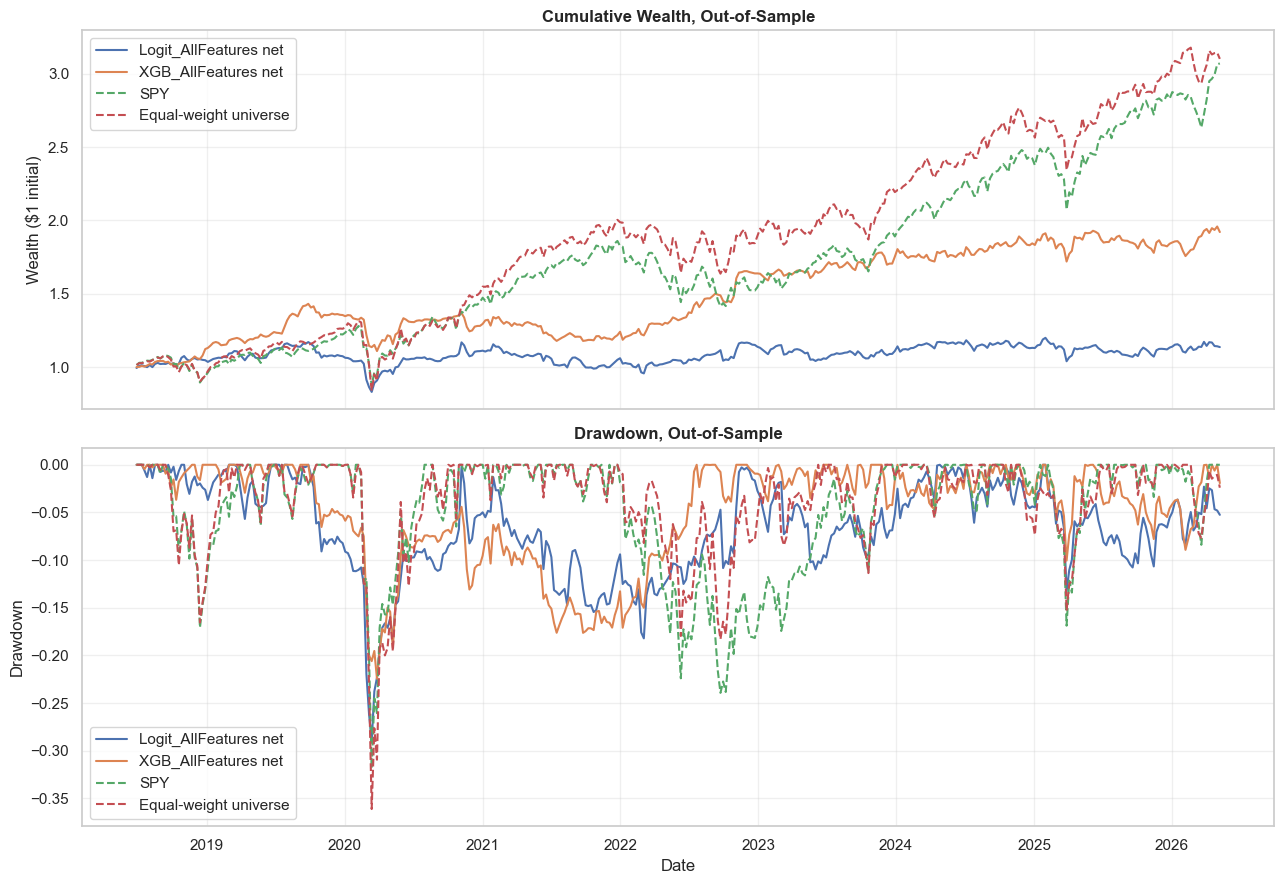

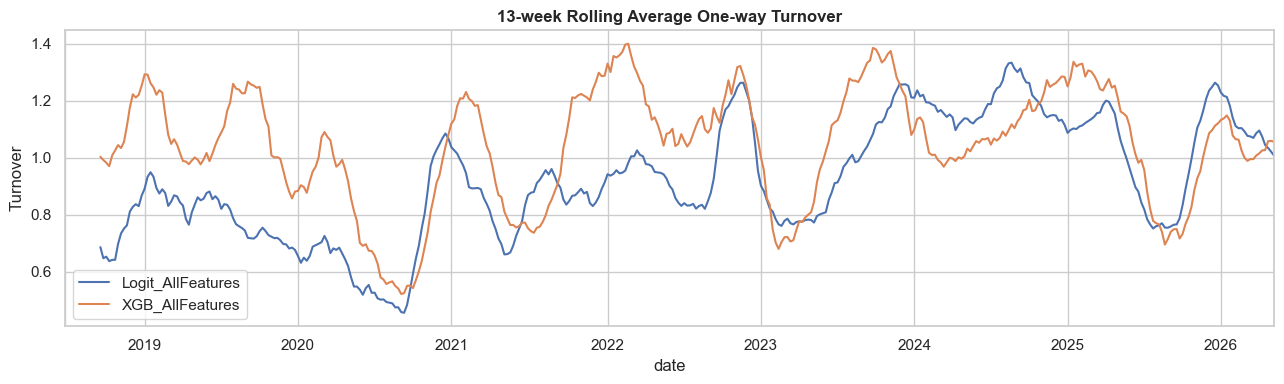

In [16]:
# =============================================================================
# 14) PLOTS
# =============================================================================

def wealth_index(r):
    return (1.0 + pd.Series(r).fillna(0.0)).cumprod()


def drawdown_series(r):
    w = wealth_index(r)
    return w / w.cummax() - 1.0


fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for model_name in main_model_names:
    r = base_returns[model_name]["net_return"]
    axes[0].plot(r.index, wealth_index(r), label=f"{model_name} net")
    axes[1].plot(r.index, drawdown_series(r), label=f"{model_name} net")

axes[0].plot(spy_oos.index, wealth_index(spy_oos), "--", label="SPY")
axes[0].plot(eqw_oos.index, wealth_index(eqw_oos), "--", label="Equal-weight universe")
axes[1].plot(spy_oos.index, drawdown_series(spy_oos), "--", label="SPY")
axes[1].plot(eqw_oos.index, drawdown_series(eqw_oos), "--", label="Equal-weight universe")

axes[0].set_title("Cumulative Wealth, Out-of-Sample")
axes[0].set_ylabel("Wealth ($1 initial)")
axes[1].set_title("Drawdown, Out-of-Sample")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
for ax in axes:
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cumulative_wealth_and_drawdown.png", dpi=180, bbox_inches="tight")
plt.show()


turnover_plot = pd.DataFrame({m: base_returns[m]["turnover"] for m in main_model_names})
ax = turnover_plot.rolling(13).mean().plot(figsize=(13, 4), title="13-week Rolling Average One-way Turnover")
ax.set_ylabel("Turnover")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rolling_turnover.png", dpi=180, bbox_inches="tight")
plt.show()

## 15) Cost Sensitivity

Transaction costs are applied as a one-way cost multiplied by one-way turnover. The base case is 5 bps; 1 bps is optimistic for very liquid institutional execution, while 10 bps is a more conservative implementation case.

In [17]:
# =============================================================================
# 15) COST SENSITIVITY
# =============================================================================

cost_rows = []
cost_return_store = {}

for cost in COST_BPS_SENSITIVITY:
    for model_name in main_model_names:
        ret_df, _ = backtest_from_predictions(
            predictions=predictions,
            model_name=model_name,
            q=QUANTILE_BASE,
            cost_bps=cost,
            apply_vol_target=APPLY_VOL_TARGET,
            vol_target_annual=VOL_TARGET_ANNUAL,
            vol_lookback=VOL_LOOKBACK_WEEKS,
            max_weight_scale=MAX_WEIGHT_SCALE,
        )
        cost_return_store[(model_name, cost)] = ret_df
        cost_rows.append(tear_sheet(ret_df, name=model_name))

cost_sensitivity = pd.DataFrame(cost_rows).sort_values(["Name", "Cost_bps"])

print("Cost sensitivity:")
display(format_performance_table(cost_sensitivity))
cost_sensitivity.to_csv(OUTPUT_DIR / "cost_sensitivity.csv", index=False)

Cost sensitivity:


,Name,Q,Cost_bps,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net
0,Logit_AllFeatures,0.2,1,4.11%,12.86%,0.38,-28.36%,3.62%,12.86%,0.34,-28.48%,92.25%,1.32
2,Logit_AllFeatures,0.2,5,4.11%,12.86%,0.38,-28.36%,1.65%,12.86%,0.19,-28.96%,92.25%,1.14
4,Logit_AllFeatures,0.2,10,4.11%,12.86%,0.38,-28.36%,-0.76%,12.87%,0.01,-29.56%,92.25%,0.94
1,XGB_AllFeatures,0.2,1,11.60%,11.75%,0.99,-21.48%,11.00%,11.74%,0.95,-21.67%,104.59%,2.28
3,XGB_AllFeatures,0.2,5,11.60%,11.75%,0.99,-21.48%,8.61%,11.74%,0.76,-22.45%,104.59%,1.92
5,XGB_AllFeatures,0.2,10,11.60%,11.75%,0.99,-21.48%,5.70%,11.73%,0.53,-23.41%,104.59%,1.55


## 16) Quantile Threshold Robustness

This check asks whether performance depends on exactly choosing the top/bottom 20%, or whether the signal is stable across narrower and wider portfolios.

In [18]:
# =============================================================================
# 16) QUANTILE ROBUSTNESS
# =============================================================================

quantile_rows = []
for q in QUANTILE_GRID:
    for model_name in main_model_names:
        ret_df, _ = backtest_from_predictions(
            predictions=predictions,
            model_name=model_name,
            q=q,
            cost_bps=COST_BPS_BASE,
            apply_vol_target=APPLY_VOL_TARGET,
            vol_target_annual=VOL_TARGET_ANNUAL,
            vol_lookback=VOL_LOOKBACK_WEEKS,
            max_weight_scale=MAX_WEIGHT_SCALE,
        )
        quantile_rows.append(tear_sheet(ret_df, name=model_name))

quantile_sensitivity = pd.DataFrame(quantile_rows).sort_values(["Name", "Q"])

print("Quantile threshold sensitivity:")
display(format_performance_table(quantile_sensitivity))
quantile_sensitivity.to_csv(OUTPUT_DIR / "quantile_sensitivity.csv", index=False)

for model_name in main_model_names:
    sub = quantile_sensitivity[quantile_sensitivity["Name"] == model_name]
    spread = sub["Sharpe_net"].max() - sub["Sharpe_net"].min()
    best_q = sub.loc[sub["Sharpe_net"].idxmax(), "Q"]
    print(f"{model_name}: net Sharpe spread across quantiles = {spread:.2f}; best q = {best_q:.0%}")

Quantile threshold sensitivity:


,Name,Q,Cost_bps,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net
0,Logit_AllFeatures,0.1,5,2.90%,14.75%,0.27,-31.32%,0.42%,14.75%,0.10,-32.70%,93.86%,1.03
2,Logit_AllFeatures,0.2,5,4.11%,12.86%,0.38,-28.36%,1.65%,12.86%,0.19,-28.96%,92.25%,1.14
4,Logit_AllFeatures,0.3,5,3.04%,11.72%,0.31,-27.79%,0.75%,11.72%,0.12,-28.29%,86.70%,1.06
1,XGB_AllFeatures,0.1,5,13.02%,13.20%,0.99,-20.62%,9.89%,13.19%,0.78,-21.73%,108.09%,2.11
3,XGB_AllFeatures,0.2,5,11.60%,11.75%,0.99,-21.48%,8.61%,11.74%,0.76,-22.45%,104.59%,1.92
5,XGB_AllFeatures,0.3,5,10.40%,10.72%,0.98,-22.64%,7.60%,10.71%,0.74,-23.53%,99.00%,1.78


Logit_AllFeatures: net Sharpe spread across quantiles = 0.09; best q = 20%
XGB_AllFeatures: net Sharpe spread across quantiles = 0.04; best q = 10%


## 17) Evidence Log

The experiment log is generated from actual walk-forward backtests above. It includes a baseline, incremental feature additions, the improved model, and an ablation that removes momentum/reversal features.

In [19]:

# =============================================================================
# 17) EVIDENCE LOG
# =============================================================================

evidence_log = base_summary.copy()
evidence_log["What_Changed"] = evidence_log["Name"].map({name: spec["experiment"] for name, spec in MODEL_SPECS.items()})
evidence_log["Interpretation"] = evidence_log.apply(
    lambda row: (
        "Improved non-linear model candidate; compare against logistic baseline."
        if row["Name"] == "XGB_AllFeatures"
        else "Ablation test: remove momentum/reversal features from XGBoost."
        if row["Name"] == "XGB_NoMomentum_Ablation"
        else "Baseline or incremental logistic feature experiment."
    ),
    axis=1,
)
evidence_log = evidence_log[[
    "Name", "What_Changed", "Q", "Cost_bps", "AnnRet_net", "AnnVol_net", "Sharpe_net", "MDD_net", "AvgTurnover", "FinalWealth_net", "Interpretation"
]]

print("Evidence log:")
display(format_performance_table(evidence_log))
evidence_log.to_csv(OUTPUT_DIR / "evidence_log.csv", index=False)


Evidence log:


,Name,What_Changed,Q,Cost_bps,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net,Interpretation
3,XGB_AllFeatures,Improved non-linear XGBoost model with all fea...,0.2,5,8.61%,11.74%,0.76,-22.45%,104.59%,1.92,Improved non-linear model candidate; compare a...
0,Logit_CoreMomentum,Baseline logistic regression with core momentu...,0.2,5,2.29%,13.58%,0.23,-24.13%,101.20%,1.20,Baseline or incremental logistic feature exper...
2,Logit_AllFeatures,"Add liquidity, drawdown, and trend features to...",0.2,5,1.65%,12.86%,0.19,-28.96%,92.25%,1.14,Baseline or incremental logistic feature exper...
4,XGB_NoMomentum_Ablation,Ablation: remove momentum/reversal features fr...,0.2,5,1.04%,12.25%,0.15,-38.54%,96.32%,1.08,Ablation test: remove momentum/reversal featur...
1,Logit_CoreVol,Add volatility/risk features to the logistic b...,0.2,5,0.63%,13.22%,0.11,-29.90%,99.04%,1.05,Baseline or incremental logistic feature exper...


## 18) Error Analysis

This section automatically identifies concrete failure cases:

1. The five worst XGBoost strategy weeks.
2. The five most severe single-name mis-rankings where the model placed a stock in a portfolio tail and the next-week outcome strongly contradicted the rank.

In [20]:
# =============================================================================
# 18) ERROR ANALYSIS
# =============================================================================

def likely_week_reason(row, spy_ret_value):
    high_turnover = row["turnover"] > base_returns["XGB_AllFeatures"]["turnover"].quantile(0.75)
    short_hurt = row["short_leg_contribution"] < row["long_leg_contribution"] and row["short_leg_contribution"] < 0
    long_hurt = row["long_leg_contribution"] < 0
    if pd.notna(spy_ret_value) and spy_ret_value < -0.03:
        return "Broad market sell-off; relative signal may be overwhelmed by market stress."
    if short_hurt:
        return "Short book detracted; low-ranked stocks outperformed over the holding week."
    if long_hurt:
        return "Long book detracted; high-ranked stocks reversed or missed the rebound."
    if high_turnover:
        return "High turnover week; trading cost amplified a weak gross return."
    return "Cross-sectional ranking failed for this week despite normal market conditions."


xgb_base = base_returns["XGB_AllFeatures"].copy()
worst_weeks = xgb_base.nsmallest(5, "net_return").reset_index()
worst_weeks["SPY_next_week_return"] = benchmark_fwd_ret.reindex(worst_weeks["date"]).values
worst_weeks["Likely_Reason"] = worst_weeks.apply(lambda r: likely_week_reason(r, r["SPY_next_week_return"]), axis=1)
worst_weeks["Possible_Fix"] = [
    "Add market-stress interaction features or cap gross exposure during high-volatility regimes.",
    "Add short-book risk controls such as borrow-cost proxy, beta-neutralization, or sector caps.",
    "Use smoother ranks or ensemble predictions to reduce sensitivity to short-horizon reversals.",
    "Add turnover penalty or no-trade buffer around rank cutoffs.",
    "Monitor rolling hit-rate and temporarily reduce risk when signal efficacy deteriorates.",
][:len(worst_weeks)]

print("Five worst XGBoost strategy weeks:")
display(worst_weeks[[
    "date", "net_return", "gross_return", "turnover", "long_leg_contribution", "short_leg_contribution",
    "SPY_next_week_return", "Likely_Reason", "Possible_Fix"
]])


xgb_pred = predictions[predictions["model"] == "XGB_AllFeatures"].copy()
xgb_pred["score_rank_pct"] = xgb_pred.groupby("date")["score"].rank(pct=True)
xgb_pred["fwd_ret_rank_pct"] = xgb_pred.groupby("date")["fwd_ret"].rank(pct=True)
xgb_pred["failure_type"] = np.where(
    (xgb_pred["score_rank_pct"] >= 1 - QUANTILE_BASE) & (xgb_pred["fwd_ret_rank_pct"] <= QUANTILE_BASE),
    "High-ranked long candidate underperformed badly",
    np.where(
        (xgb_pred["score_rank_pct"] <= QUANTILE_BASE) & (xgb_pred["fwd_ret_rank_pct"] >= 1 - QUANTILE_BASE),
        "Low-ranked short candidate outperformed badly",
        ""
    )
)
misranked = xgb_pred[xgb_pred["failure_type"] != ""].copy()
misranked["severity"] = (misranked["score_rank_pct"] - misranked["fwd_ret_rank_pct"]).abs()
misranked = misranked.sort_values(["severity", "date"], ascending=[False, True]).head(5)
misranked["Possible_Fix"] = np.where(
    misranked["failure_type"].str.contains("long"),
    "Add event-risk filters, earnings calendar controls, or reduce weight for names with unstable recent volatility.",
    "Add short squeeze / crowded short proxies and sector-neutral ranking before short selection."
)

print("\nFive severe single-name mis-rankings:")
display(misranked[[
    "date", "ticker", "score", "score_rank_pct", "fwd_ret", "fwd_ret_rank_pct", "failure_type", "Possible_Fix"
]])

worst_weeks.to_csv(OUTPUT_DIR / "error_analysis_worst_weeks.csv", index=False)
misranked.to_csv(OUTPUT_DIR / "error_analysis_misranked_stocks.csv", index=False)

Five worst XGBoost strategy weeks:


,date,net_return,gross_return,turnover,long_leg_contribution,short_leg_contribution,SPY_next_week_return,Likely_Reason,Possible_Fix
0,2020-02-28,-0.079298,-0.078548,1.499888,-0.051117,-0.027431,0.004050,Long book detracted; high-ranked stocks revers...,Add market-stress interaction features or cap ...
1,2020-03-06,-0.060433,-0.059925,1.015491,-0.122574,0.062648,-0.094601,Broad market sell-off; relative signal may be ...,Add short-book risk controls such as borrow-co...
2,2025-03-28,-0.049402,-0.048900,1.003512,-0.116058,0.067158,-0.090667,Broad market sell-off; relative signal may be ...,Use smoother ranks or ensemble predictions to ...
3,2020-11-20,-0.047314,-0.046758,1.110428,0.010677,-0.057435,0.023471,Short book detracted; low-ranked stocks outper...,Add turnover penalty or no-trade buffer around...
4,2020-05-08,-0.044291,-0.044077,0.429351,-0.050685,0.006609,-0.021064,Long book detracted; high-ranked stocks revers...,Monitor rolling hit-rate and temporarily reduc...



Five severe single-name mis-rankings:


,date,ticker,score,score_rank_pct,fwd_ret,fwd_ret_rank_pct,failure_type,Possible_Fix
185938,2020-01-10,EQT,0.537077,1.000000,-0.067873,0.002169,High-ranked long candidate underperformed badly,"Add event-risk filters, earnings calendar cont..."
294484,2020-12-04,SATS,0.550432,1.000000,-0.092295,0.002169,High-ranked long candidate underperformed badly,"Add event-risk filters, earnings calendar cont..."
347572,2021-05-14,WBD,0.547368,1.000000,-0.117251,0.002169,High-ranked long candidate underperformed badly,"Add event-risk filters, earnings calendar cont..."
506530,2022-09-09,RCL,0.379307,0.002169,0.067739,1.000000,Low-ranked short candidate outperformed badly,Add short squeeze / crowded short proxies and ...
672511,2024-01-26,SMCI,0.440605,0.002169,0.222461,1.000000,Low-ranked short candidate outperformed badly,Add short squeeze / crowded short proxies and ...


## 19) Risk Management, Limitations, and Governance

**Risk controls used here.**

- Equal weighting caps single-name concentration within each leg.
- Top/bottom quantile portfolios diversify away from one-name bets.
- Optional volatility targeting scales the book down when trailing realized strategy volatility exceeds the 10% annualized target.
- Transaction-cost sensitivity tests whether the signal survives plausible execution assumptions.

**Main limitations.**

- Current-constituent universe creates survivorship bias.
- Yahoo Finance data is adjusted and not a fully point-in-time institutional database.
- Short borrow fees, locate constraints, financing, taxes, and market impact are not modelled.
- No sector neutrality or beta neutrality is imposed.
- The model uses technical/liquidity features only; no fundamentals, estimates, news, or earnings calendar controls.

**Monitoring plan.** In production, the PM should monitor rolling net Sharpe, rolling hit-rate, turnover, realized transaction costs, factor/sector exposures, feature drift, and prediction calibration. A practical governance trigger would be a review if 13-week net performance falls below the equal-weight universe by more than 5%, or if turnover/costs exceed the backtest 90th percentile for four consecutive weeks.

## 20) Conditional Leakage Audit Discussion

The A3 brief requires an expanded leakage audit if out-of-sample net Sharpe exceeds 2.0. This notebook prints the trigger below and includes the checklist regardless of the result.

In [21]:
# =============================================================================
# 20) CONDITIONAL LEAKAGE AUDIT
# =============================================================================

print("Net Sharpe leakage trigger check (base 5 bps, q=20%):")
for model_name in main_model_names:
    s = base_summary.loc[base_summary["Name"] == model_name, "Sharpe_net"].iloc[0]
    if s > 2.0:
        print(f"  WARNING: {model_name} net Sharpe = {s:.2f} > 2.0. Expanded leakage audit required in the report.")
    else:
        print(f"  OK: {model_name} net Sharpe = {s:.2f}. Still disclose the leakage controls and survivorship limitation.")

print("\nFalsification check: shuffle XGBoost scores within each date.")
shuffled_pred = predictions[predictions["model"] == "XGB_AllFeatures"].copy()
rng = np.random.default_rng(RANDOM_SEED)
shuffled_pred["score"] = shuffled_pred.groupby("date")["score"].transform(lambda s: rng.permutation(s.to_numpy()))
shuffle_ret, _ = backtest_from_predictions(
    predictions=shuffled_pred,
    model_name="XGB_AllFeatures",
    q=QUANTILE_BASE,
    cost_bps=COST_BPS_BASE,
    apply_vol_target=APPLY_VOL_TARGET,
    vol_target_annual=VOL_TARGET_ANNUAL,
    vol_lookback=VOL_LOOKBACK_WEEKS,
    max_weight_scale=MAX_WEIGHT_SCALE,
)
falsification_summary = pd.DataFrame([tear_sheet(shuffle_ret, name="XGBoost scores shuffled within date")])
display(format_performance_table(falsification_summary))
falsification_summary.to_csv(OUTPUT_DIR / "falsification_shuffled_scores.csv", index=False)

print(dedent("""
Expanded audit items to discuss if triggered:
  1. Verify all rolling features are backward-looking and include no t+1 returns.
  2. Confirm target construction uses groupby(date) median of next-week returns only as the label, never as a feature.
  3. Confirm train/test splits are date-based and no date appears in both train and test.
  4. Confirm SimpleImputer and StandardScaler are inside the Pipeline and fit only on training rows.
  5. Confirm universe construction limitations are disclosed: current constituents and continuous-history screen are not point-in-time.
  6. Re-run a falsification test with shuffled labels; a strong Sharpe after shuffling would indicate leakage or overfitting.
"""))

Net Sharpe leakage trigger check (base 5 bps, q=20%):
  OK: Logit_AllFeatures net Sharpe = 0.19. Still disclose the leakage controls and survivorship limitation.
  OK: XGB_AllFeatures net Sharpe = 0.76. Still disclose the leakage controls and survivorship limitation.

Falsification check: shuffle XGBoost scores within each date.


,Name,Q,Cost_bps,AnnRet_gross,AnnVol_gross,Sharpe_gross,MDD_gross,AnnRet_net,AnnVol_net,Sharpe_net,MDD_net,AvgTurnover,FinalWealth_net
0,XGBoost scores shuffled within date,0.2,5,-1.02%,5.54%,-0.16,-13.85%,-6.84%,5.54%,-1.25,-44.35%,232.64%,0.57



Expanded audit items to discuss if triggered:
  1. Verify all rolling features are backward-looking and include no t+1 returns.
  2. Confirm target construction uses groupby(date) median of next-week returns only as the label, never as a feature.
  3. Confirm train/test splits are date-based and no date appears in both train and test.
  4. Confirm SimpleImputer and StandardScaler are inside the Pipeline and fit only on training rows.
  5. Confirm universe construction limitations are disclosed: current constituents and continuous-history screen are not point-in-time.
  6. Re-run a falsification test with shuffled labels; a strong Sharpe after shuffling would indicate leakage or overfitting.



## 21c) Strategy Diagnostics and Optimization Ideas

These diagnostics explain why the long-short strategy can have mildly positive gross performance but weak net performance. The core questions are:

- Is the short leg helping, or is it noisy and costly?
- Is ranking power visible in top-minus-bottom realized returns and rank IC?
- Is turnover large enough to consume the gross edge?
- Does q=30% look better because the signal is broad but noisy?

If q=30% is more stable than q=20%, the practical interpretation is that diversification may matter more than concentration. A no-trade buffer is a natural next experiment: enter the top 20%, but only sell an existing holding if it falls below the top 30%. That can reduce turnover, but it is left as a future improvement to keep this notebook runtime reasonable. A monthly rebalance comparison and sector-neutral ranking are also sensible next steps.

In [22]:

# =============================================================================
# 21c) STRATEGY DIAGNOSTICS AND OPTIMIZATION IDEAS
# =============================================================================

def cross_section_signal_stats(pred, q=0.20):
    rows = []
    for date, x in pred.groupby("date"):
        x = x.dropna(subset=["score", "fwd_ret", "target"]).sort_values("score", ascending=False)
        if len(x) < 10:
            continue
        n_leg = max(1, int(np.floor(len(x) * q)))
        top = x.head(n_leg)
        bottom = x.tail(n_leg)
        rows.append({
            "date": date,
            "q": q,
            "rank_ic_spearman": x["score"].corr(x["fwd_ret"], method="spearman"),
            "top_hit_rate": top["target"].mean(),
            "bottom_hit_rate": 1.0 - bottom["target"].mean(),
            "top_minus_bottom_realized_return": top["fwd_ret"].mean() - bottom["fwd_ret"].mean(),
            "top_avg_fwd_return": top["fwd_ret"].mean(),
            "bottom_avg_fwd_return": bottom["fwd_ret"].mean(),
        })
    return pd.DataFrame(rows)


diagnostic_rows = []
diagnostic_detail_frames = []
turnover_distribution_rows = []
turnover_net_return_frames = []
long_short_diagnostic_returns = {}

for model_name in main_model_names:
    pred_m = predictions[predictions["model"] == model_name].copy()
    for q in [0.20, 0.30]:
        if np.isclose(q, QUANTILE_BASE):
            ls_ret = base_returns[model_name]
        else:
            ls_ret, _ = backtest_from_predictions(
                predictions=predictions,
                model_name=model_name,
                q=q,
                cost_bps=COST_BPS_BASE,
                apply_vol_target=APPLY_VOL_TARGET,
                vol_target_annual=VOL_TARGET_ANNUAL,
                vol_lookback=VOL_LOOKBACK_WEEKS,
                max_weight_scale=MAX_WEIGHT_SCALE,
            )
        long_short_diagnostic_returns[(model_name, q)] = ls_ret

        cs_stats = cross_section_signal_stats(pred_m, q=q)
        cs_stats["model"] = model_name
        diagnostic_detail_frames.append(cs_stats)

        diagnostic_rows.append({
            "Model": model_name,
            "Q": q,
            "Avg_Long_Leg_Contribution": ls_ret["long_leg_contribution"].mean(),
            "Avg_Short_Leg_Contribution": ls_ret["short_leg_contribution"].mean(),
            "Pct_Weeks_Long_Leg_Positive": (ls_ret["long_leg_contribution"] > 0).mean(),
            "Pct_Weeks_Short_Leg_Positive": (ls_ret["short_leg_contribution"] > 0).mean(),
            "Avg_TopMinusBottom_Spread": cs_stats["top_minus_bottom_realized_return"].mean(),
            "Avg_Rank_IC": cs_stats["rank_ic_spearman"].mean(),
            "Pct_Positive_Rank_IC": (cs_stats["rank_ic_spearman"] > 0).mean(),
            "Avg_Top_Hit_Rate": cs_stats["top_hit_rate"].mean(),
            "Avg_Bottom_Hit_Rate": cs_stats["bottom_hit_rate"].mean(),
            "AvgTurnover": ls_ret["turnover"].mean(),
            "Turnover_P95": ls_ret["turnover"].quantile(0.95),
            "NetSharpe": sharpe_ratio(ls_ret["net_return"]),
            "GrossSharpe": sharpe_ratio(ls_ret["gross_return"]),
        })

        desc = ls_ret["turnover"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).to_dict()
        desc.update({"Model": model_name, "Q": q})
        turnover_distribution_rows.append(desc)

        scatter = ls_ret[["net_return", "gross_return", "turnover"]].reset_index()
        scatter["Model"] = model_name
        scatter["Q"] = q
        turnover_net_return_frames.append(scatter)

strategy_diagnostics = pd.DataFrame(diagnostic_rows).sort_values(["Model", "Q"])
signal_diagnostics_by_date = pd.concat(diagnostic_detail_frames, ignore_index=True)
turnover_distribution = pd.DataFrame(turnover_distribution_rows)
turnover_vs_net_return = pd.concat(turnover_net_return_frames, ignore_index=True)

score_quintile_forward_returns = (
    predictions[predictions["model"] == "XGB_AllFeatures"]
    .dropna(subset=["score", "fwd_ret"])
    .assign(score_quintile=lambda x: x.groupby("date")["score"].transform(lambda s: pd.qcut(s.rank(method="first"), 5, labels=False) + 1))
    .groupby("score_quintile", as_index=False)["fwd_ret"]
    .mean()
)
score_quintile_forward_returns["score_quintile"] = score_quintile_forward_returns["score_quintile"].astype(int)

print("Strategy diagnostics:")
display(format_performance_table(strategy_diagnostics.rename(columns={
    "NetSharpe": "Sharpe_net",
    "GrossSharpe": "Sharpe_gross",
})))

print("\nScore quintile average next-week returns, XGBoost:")
display(score_quintile_forward_returns)

strategy_diagnostics.to_csv(OUTPUT_DIR / "strategy_diagnostics.csv", index=False)
signal_diagnostics_by_date.to_csv(OUTPUT_DIR / "signal_diagnostics_by_date.csv", index=False)
turnover_distribution.to_csv(OUTPUT_DIR / "turnover_distribution.csv", index=False)
turnover_vs_net_return.to_csv(OUTPUT_DIR / "turnover_vs_net_return.csv", index=False)
score_quintile_forward_returns.to_csv(OUTPUT_DIR / "score_quintile_forward_returns.csv", index=False)

print(dedent("""
Diagnostic interpretation guide:
  - If gross Sharpe is mildly positive but net Sharpe is weak, turnover and transaction costs are likely consuming the edge.
  - If q=30% performs better than q=20%, the signal may be broad but noisy; a wider portfolio can diversify ranking errors.
  - If the short leg contribution is negative on average, the short book is noisy and may need stronger risk controls or lower turnover.
  - If average rank IC is near zero, the model has weak cross-sectional ranking power even if some periods look good.
"""))


Strategy diagnostics:


,Model,Q,Avg_Long_Leg_Contribution,Avg_Short_Leg_Contribution,Pct_Weeks_Long_Leg_Positive,Pct_Weeks_Short_Leg_Positive,Avg_TopMinusBottom_Spread,Avg_Rank_IC,Pct_Positive_Rank_IC,Avg_Top_Hit_Rate,Avg_Bottom_Hit_Rate,AvgTurnover,Turnover_P95,Sharpe_net,Sharpe_gross
0,Logit_AllFeatures,0.2,0.002949,-0.002014,0.574209,0.416058,0.001713,0.015290,0.530414,0.510129,0.511927,92.25%,1.370816,0.19,0.38
1,Logit_AllFeatures,0.3,0.003103,-0.002393,0.574209,0.399027,0.001206,0.015290,0.530414,0.506753,0.507105,86.70%,1.322363,0.12,0.31
2,XGB_AllFeatures,0.2,0.004193,-0.001949,0.593674,0.425791,0.002613,0.025736,0.552311,0.515894,0.512483,104.59%,1.592020,0.76,0.99
3,XGB_AllFeatures,0.3,0.004280,-0.002266,0.586375,0.425791,0.002108,0.025736,0.552311,0.513629,0.511178,99.00%,1.555322,0.74,0.98



Score quintile average next-week returns, XGBoost:


,score_quintile,fwd_ret
0,1,0.002346
1,2,0.002430
2,3,0.002591
3,4,0.003361
4,5,0.004961



Diagnostic interpretation guide:
  - If gross Sharpe is mildly positive but net Sharpe is weak, turnover and transaction costs are likely consuming the edge.
  - If q=30% performs better than q=20%, the signal may be broad but noisy; a wider portfolio can diversify ranking errors.
  - If the short leg contribution is negative on average, the short book is noisy and may need stronger risk controls or lower turnover.
  - If average rank IC is near zero, the model has weak cross-sectional ranking power even if some periods look good.



## 22) Report and Presentation Asset Export

This final asset-export section writes report/PPT-ready figures as PNG and key tables as both CSV and LaTeX. The goal is to avoid screenshots of notebook outputs and make the final report easier to assemble cleanly.

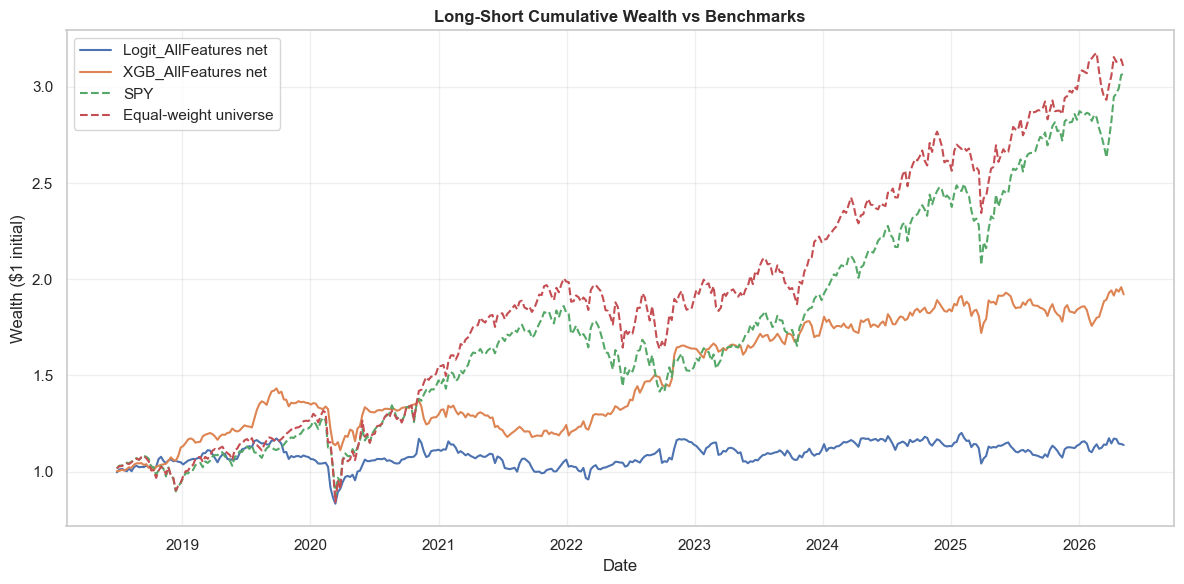

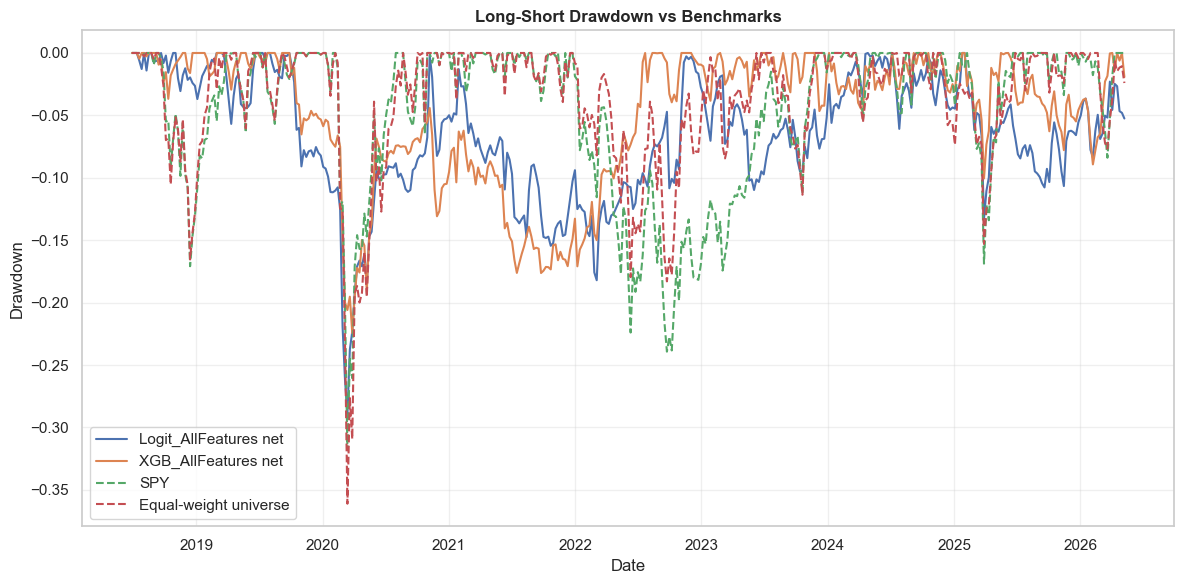

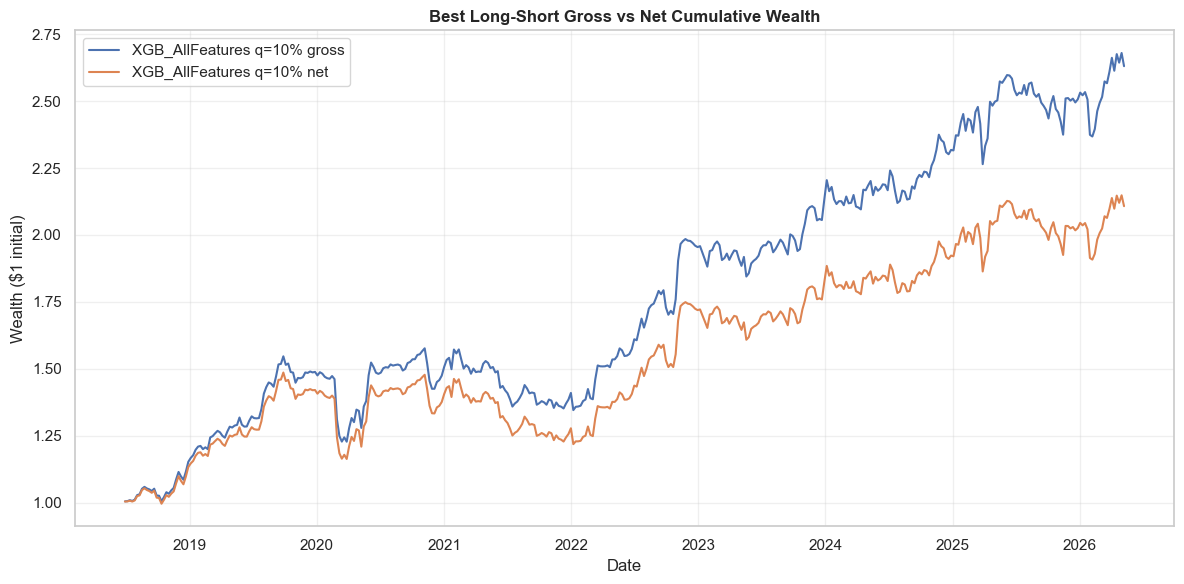

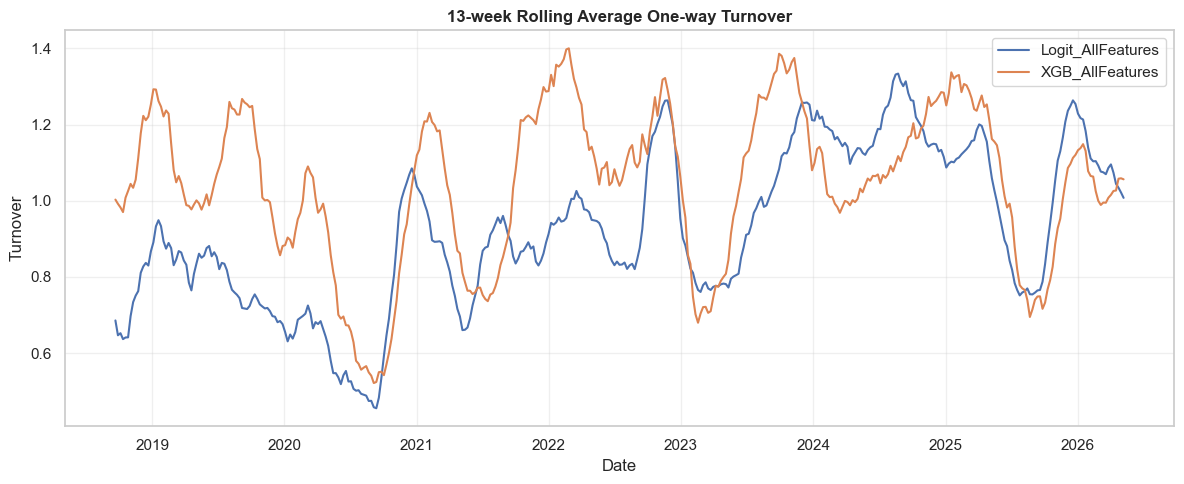

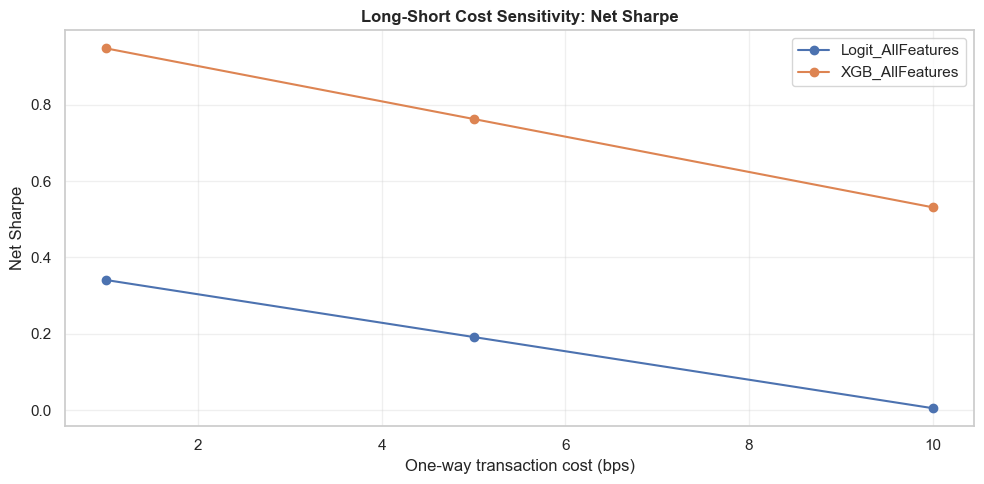

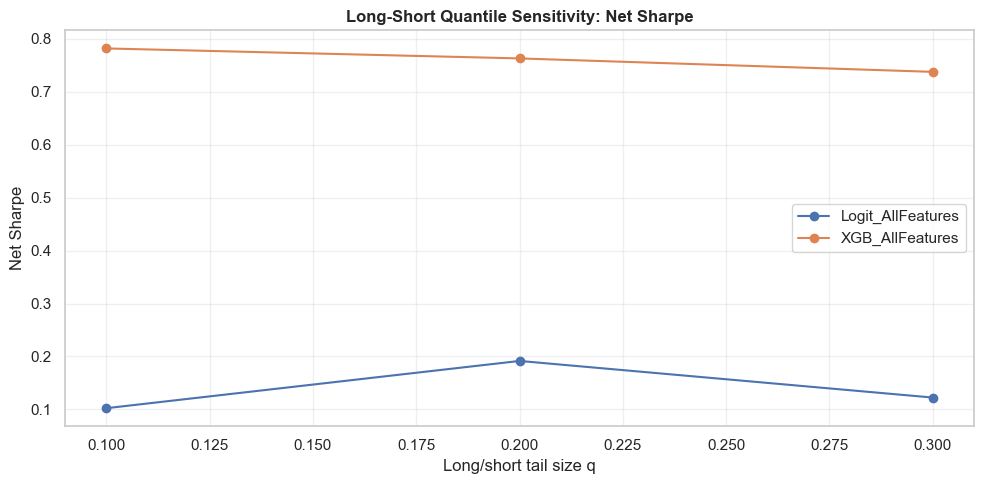

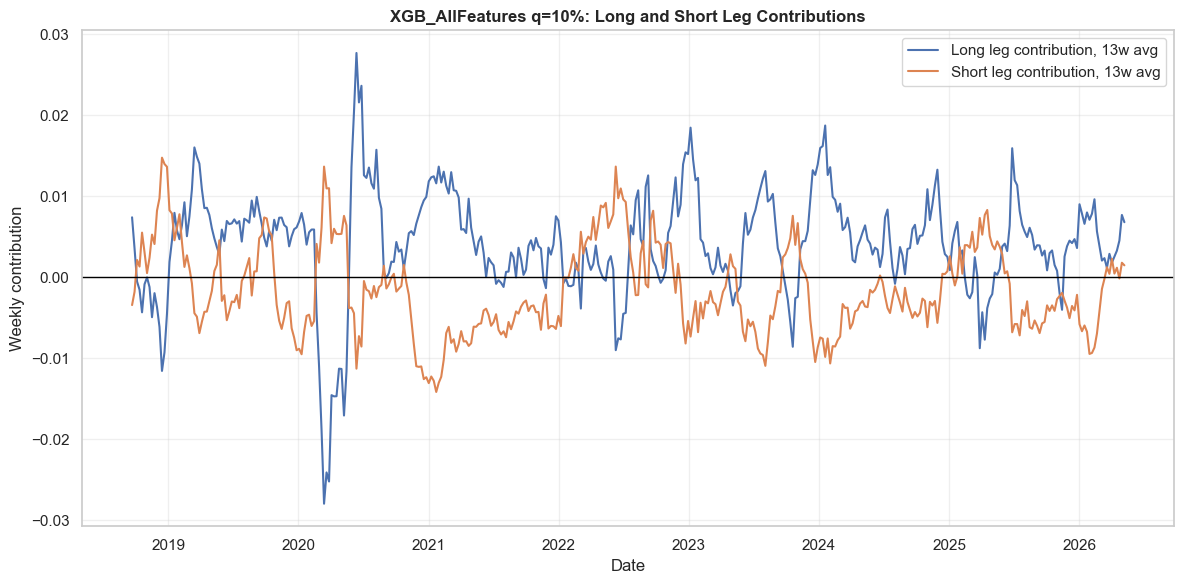

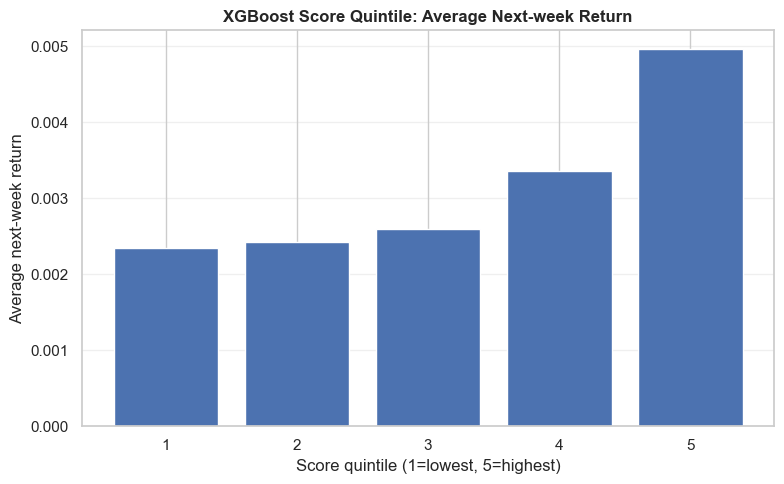

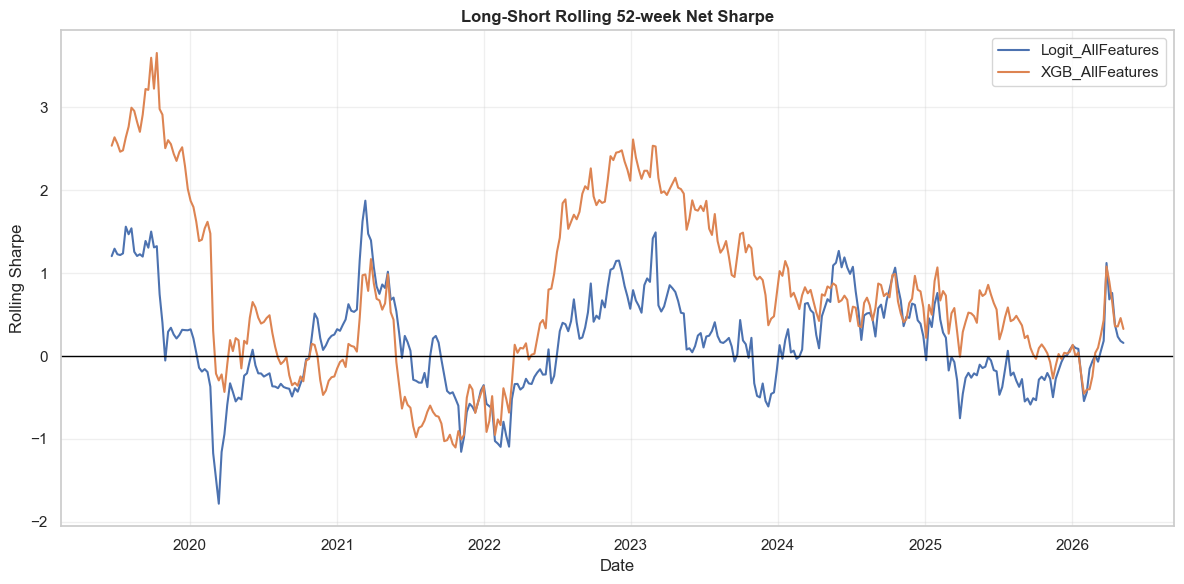

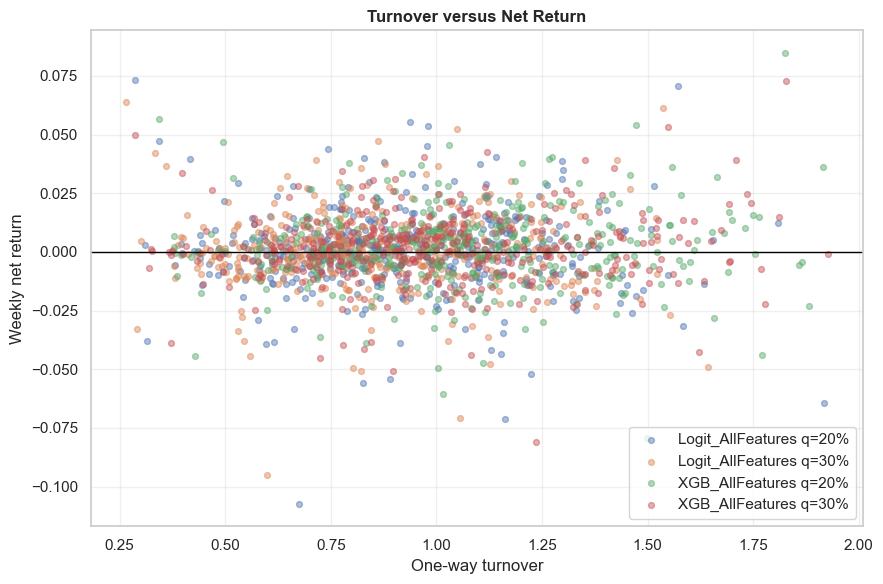

Report/PPT figures saved to: /Users/mingwang/Desktop/Finc 6028 A3/a3_outputs/report_assets/figures
Report/PPT tables saved to:  /Users/mingwang/Desktop/Finc 6028 A3/a3_outputs/report_assets/tables


In [23]:

# =============================================================================
# 22) REPORT AND PRESENTATION ASSET EXPORT
# =============================================================================

REPORT_DIR = OUTPUT_DIR / "report_assets"
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(path):
    """Save the current matplotlib figure with report-ready defaults."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=250, bbox_inches="tight", facecolor="white")
    return path


def _report_table(df):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = pd.to_datetime(out[col]).dt.strftime("%Y-%m-%d")
    return out


def save_latex_table(df, filename, caption=None, label=None, index=False):
    """Save a booktabs-style LaTeX table and a matching CSV copy."""
    filename = filename.replace(".tex", "")
    table = _report_table(df)
    tex_path = TABLE_DIR / f"{filename}.tex"
    csv_path = TABLE_DIR / f"{filename}.csv"
    root_tex_path = OUTPUT_DIR / f"{filename}.tex"
    root_csv_path = OUTPUT_DIR / f"{filename}.csv"

    table.to_csv(csv_path, index=index)
    table.to_csv(root_csv_path, index=index)
    latex = table.to_latex(
        index=index,
        escape=False,
        float_format=lambda x: f"{x:.4f}",
        caption=caption,
        label=label,
        longtable=False,
        bold_rows=False,
    )
    tex_path.write_text(latex, encoding="utf-8")
    root_tex_path.write_text(latex, encoding="utf-8")
    return tex_path


def save_report_figure(filename):
    save_figure(FIGURE_DIR / filename)
    save_figure(OUTPUT_DIR / filename)


report_tables = {
    "main_model_comparison": main_summary,
    "base_experiment_performance": base_summary,
    "benchmark_summary": benchmark_summary,
    "cost_sensitivity": cost_sensitivity,
    "quantile_sensitivity": quantile_sensitivity,
    "evidence_log": evidence_log,
    "feature_table": feature_table,
    "cleaning_summary": cleaning_summary,
    "missingness_summary": missingness_summary,
    "worst_weeks": worst_weeks,
    "misranked_stocks": misranked,
    "strategy_diagnostics": strategy_diagnostics,
    "turnover_distribution": turnover_distribution,
    "score_quintile_forward_returns": score_quintile_forward_returns,
    "falsification_shuffled_scores": falsification_summary,
}

for table_name, table in report_tables.items():
    save_latex_table(
        table,
        table_name,
        caption=table_name.replace("_", " ").title(),
        label=f"tab:{table_name}",
        index=False,
    )


# Figure 1: long-short cumulative wealth vs benchmarks.
plt.figure(figsize=(12, 6))
for model_name in main_model_names:
    r = base_returns[model_name]["net_return"]
    plt.plot(r.index, wealth_index(r), label=f"{model_name} net")
plt.plot(spy_oos.index, wealth_index(spy_oos), "--", label="SPY")
plt.plot(eqw_oos.index, wealth_index(eqw_oos), "--", label="Equal-weight universe")
plt.title("Long-Short Cumulative Wealth vs Benchmarks")
plt.ylabel("Wealth ($1 initial)")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("long_short_cumulative_wealth.png")
plt.show()


# Figure 2: long-short drawdown vs benchmarks.
plt.figure(figsize=(12, 6))
for model_name in main_model_names:
    r = base_returns[model_name]["net_return"]
    plt.plot(r.index, drawdown_series(r), label=f"{model_name} net")
plt.plot(spy_oos.index, drawdown_series(spy_oos), "--", label="SPY")
plt.plot(eqw_oos.index, drawdown_series(eqw_oos), "--", label="Equal-weight universe")
plt.title("Long-Short Drawdown vs Benchmarks")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("long_short_drawdown.png")
plt.show()


# Figure 3: gross vs net cumulative wealth for the best long-short model.
best_long_short_for_plot = quantile_sensitivity.sort_values("Sharpe_net", ascending=False).iloc[0]
plot_model = best_long_short_for_plot["Name"]
plot_q = best_long_short_for_plot["Q"]
if np.isclose(plot_q, QUANTILE_BASE):
    best_ls_returns = base_returns[plot_model]
else:
    best_ls_returns, _ = backtest_from_predictions(
        predictions=predictions,
        model_name=plot_model,
        q=plot_q,
        cost_bps=COST_BPS_BASE,
        apply_vol_target=APPLY_VOL_TARGET,
        vol_target_annual=VOL_TARGET_ANNUAL,
        vol_lookback=VOL_LOOKBACK_WEEKS,
        max_weight_scale=MAX_WEIGHT_SCALE,
    )

plt.figure(figsize=(12, 6))
plt.plot(best_ls_returns.index, wealth_index(best_ls_returns["gross_return"]), label=f"{plot_model} q={plot_q:.0%} gross")
plt.plot(best_ls_returns.index, wealth_index(best_ls_returns["net_return"]), label=f"{plot_model} q={plot_q:.0%} net")
plt.title("Best Long-Short Gross vs Net Cumulative Wealth")
plt.ylabel("Wealth ($1 initial)")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("best_long_short_gross_vs_net_cumulative.png")
plt.show()


# Figure 4: rolling 13-week turnover.
turnover_plot = pd.DataFrame({m: base_returns[m]["turnover"] for m in main_model_names})
plt.figure(figsize=(12, 5))
for col in turnover_plot.columns:
    plt.plot(turnover_plot.index, turnover_plot[col].rolling(13).mean(), label=col)
plt.title("13-week Rolling Average One-way Turnover")
plt.ylabel("Turnover")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("rolling_13w_turnover.png")
plt.show()


# Figure 5: cost sensitivity plot.
plt.figure(figsize=(10, 5))
for model_name, sub in cost_sensitivity.groupby("Name"):
    plt.plot(sub["Cost_bps"], sub["Sharpe_net"], marker="o", label=model_name)
plt.title("Long-Short Cost Sensitivity: Net Sharpe")
plt.xlabel("One-way transaction cost (bps)")
plt.ylabel("Net Sharpe")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("cost_sensitivity_net_sharpe.png")
plt.show()


# Figure 6: quantile sensitivity plot.
plt.figure(figsize=(10, 5))
for model_name, sub in quantile_sensitivity.groupby("Name"):
    plt.plot(sub["Q"], sub["Sharpe_net"], marker="o", label=model_name)
plt.title("Long-Short Quantile Sensitivity: Net Sharpe")
plt.xlabel("Long/short tail size q")
plt.ylabel("Net Sharpe")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("quantile_sensitivity_net_sharpe.png")
plt.show()


# Figure 7: long and short leg contributions.
plt.figure(figsize=(12, 6))
plt.plot(best_ls_returns.index, best_ls_returns["long_leg_contribution"].rolling(13).mean(), label="Long leg contribution, 13w avg")
plt.plot(best_ls_returns.index, best_ls_returns["short_leg_contribution"].rolling(13).mean(), label="Short leg contribution, 13w avg")
plt.axhline(0, color="black", linewidth=1)
plt.title(f"{plot_model} q={plot_q:.0%}: Long and Short Leg Contributions")
plt.ylabel("Weekly contribution")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("long_short_leg_contributions.png")
plt.show()


# Figure 8: score quintile forward return plot.
plt.figure(figsize=(8, 5))
plt.bar(score_quintile_forward_returns["score_quintile"], score_quintile_forward_returns["fwd_ret"])
plt.title("XGBoost Score Quintile: Average Next-week Return")
plt.xlabel("Score quintile (1=lowest, 5=highest)")
plt.ylabel("Average next-week return")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
save_report_figure("score_quintile_forward_return.png")
plt.show()


# Figure 9: rolling 52-week Sharpe.
def rolling_sharpe(r, window=52):
    r = pd.Series(r).dropna()
    return r.rolling(window).mean() / r.rolling(window).std() * np.sqrt(52)


plt.figure(figsize=(12, 6))
for model_name in main_model_names:
    plt.plot(base_returns[model_name].index, rolling_sharpe(base_returns[model_name]["net_return"]), label=model_name)
plt.axhline(0, color="black", linewidth=1)
plt.title("Long-Short Rolling 52-week Net Sharpe")
plt.ylabel("Rolling Sharpe")
plt.xlabel("Date")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("rolling_52w_long_short_sharpe.png")
plt.show()


# Figure 10: turnover versus net return scatter.
plt.figure(figsize=(9, 6))
for (model_name, q), sub in turnover_vs_net_return.groupby(["Model", "Q"]):
    plt.scatter(sub["turnover"], sub["net_return"], alpha=0.45, s=18, label=f"{model_name} q={q:.0%}")
plt.axhline(0, color="black", linewidth=1)
plt.title("Turnover versus Net Return")
plt.xlabel("One-way turnover")
plt.ylabel("Weekly net return")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_report_figure("turnover_vs_net_return.png")
plt.show()

print(f"Report/PPT figures saved to: {FIGURE_DIR.resolve()}")
print(f"Report/PPT tables saved to:  {TABLE_DIR.resolve()}")


## 23) Final Summary

This cell gives a compact run summary for reproducibility evidence and for the report appendix.

In [25]:

# =============================================================================
# 23) FINAL SUMMARY
# =============================================================================

best_long_short = quantile_sensitivity.sort_values("Sharpe_net", ascending=False).iloc[0]
best_main = main_summary.sort_values("Sharpe_net", ascending=False).iloc[0]
logit_base = main_summary.loc[main_summary["Name"] == "Logit_AllFeatures"].iloc[0]
xgb_base = main_summary.loc[main_summary["Name"] == "XGB_AllFeatures"].iloc[0]

q_message = (
    "The robustness grid suggests q=30% is more stable than the 20% base case."
    if np.isclose(best_long_short["Q"], 0.30)
    else "The 20% base case remains the strongest setting in the robustness grid."
    if np.isclose(best_long_short["Q"], 0.20)
    else "The 10% concentrated setting is strongest in the robustness grid, but should be interpreted cautiously."
)

if xgb_base["Sharpe_net"] > logit_base["Sharpe_net"]:
    model_message = (
        "The improved XGBoost model outperforms the logistic baseline under the same features, "
        "walk-forward design, and transaction cost assumptions."
    )
else:
    model_message = (
        "The improved XGBoost model does not outperform the logistic baseline in this run, "
        "so model risk should be discussed explicitly."
    )

print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Universe source: {universe_source}")
print(f"Candidate S&P 500 tickers from source: {len(sp500_candidates)}")
print(f"Selected tickers after data-quality screens: {len(selected_tickers)}")
print(f"Sample after features: {data['date'].min().date()} to {data['date'].max().date()}")
print(f"OOS period: {base_returns['XGB_AllFeatures'].index.min().date()} to {base_returns['XGB_AllFeatures'].index.max().date()}")
print(
    f"Logistic baseline (q=20%, 5 bps): Sharpe={logit_base['Sharpe_net']:.2f} | "
    f"AnnRet={logit_base['AnnRet_net']:.2%} | MDD={logit_base['MDD_net']:.2%}"
)
print(
    f"XGBoost improved model (q=20%, 5 bps): Sharpe={xgb_base['Sharpe_net']:.2f} | "
    f"AnnRet={xgb_base['AnnRet_net']:.2%} | MDD={xgb_base['MDD_net']:.2%}"
)
print(
    f"Best base long-short model: {best_main['Name']} | "
    f"Sharpe={best_main['Sharpe_net']:.2f} | AnnRet={best_main['AnnRet_net']:.2%}"
)
print(
    f"Recommended long-short robustness setting: {best_long_short['Name']} q={best_long_short['Q']:.0%} | "
    f"Sharpe={best_long_short['Sharpe_net']:.2f} | AnnRet={best_long_short['AnnRet_net']:.2%} | "
    f"MDD={best_long_short['MDD_net']:.2%} | AvgTurnover={best_long_short['AvgTurnover']:.2%}"
)
print(q_message)
print(model_message)
print("Results should still be interpreted cautiously because the universe uses a frozen current-constituent file, not point-in-time membership, and transaction costs, borrow costs, and sector/beta constraints are simplified.")
print(f"CSV outputs saved to:                  {OUTPUT_DIR.resolve()}")
print(f"Report/PPT figure assets saved to:     {FIGURE_DIR.resolve()}")
print(f"Report/PPT LaTeX/CSV tables saved to:  {TABLE_DIR.resolve()}")
print("\nRemaining limitations:")
print("  - Universe uses a frozen current-constituent file, not point-in-time S&P 500 membership.")
print("  - yfinance is not an institutional point-in-time data source.")
print("  - Short borrow fees, market impact, financing, and sector/beta constraints are simplified or omitted.")
print("  - No manual intervention required, assuming the frozen universe CSV is present and internet access is available for yfinance price downloads.")


FINAL SUMMARY
Universe source: Frozen modelling universe from a3_frozen_universe_2026-05-22.csv (461 tickers)
Candidate S&P 500 tickers from source: 461
Selected tickers after data-quality screens: 461
Sample after features: 2015-07-03 to 2026-05-08
OOS period: 2018-06-29 to 2026-05-08
Logistic baseline (q=20%, 5 bps): Sharpe=0.19 | AnnRet=1.65% | MDD=-28.96%
XGBoost improved model (q=20%, 5 bps): Sharpe=0.76 | AnnRet=8.61% | MDD=-22.45%
Best base long-short model: XGB_AllFeatures | Sharpe=0.76 | AnnRet=8.61%
Recommended long-short robustness setting: XGB_AllFeatures q=10% | Sharpe=0.78 | AnnRet=9.89% | MDD=-21.73% | AvgTurnover=108.09%
The 10% concentrated setting is strongest in the robustness grid, but should be interpreted cautiously.
The improved XGBoost model outperforms the logistic baseline under the same features, walk-forward design, and transaction cost assumptions.
Results should still be interpreted cautiously because the universe uses a frozen current-constituent file, no